# GCN baseline on Twitch graphs

This notebook is a Colab-ready implementation of the **GCN baseline** for the Twitch node-classification project.

It follows the same overall style as the MLP notebook:
- install packages
- load Twitch graphs manually from public raw MUSAE files
- create stratified train/val/test splits
- train a **full-batch GCN** with early stopping
- evaluate across multiple seeds
- save CSV metrics and figures
- run lightweight GCN ablations

In [1]:
# ============================================================
# Cell 1: Install packages (Colab-safe)
# ============================================================
!pip -q install --upgrade pip
!pip -q install pandas matplotlib scikit-learn networkx torch torchvision torchaudio
!pip -q install torch-geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.7 MB/s eta 0:00:00


In [2]:
# ============================================================
# Cell 2: Imports, global config, and output folders
# ============================================================
import os
import json
import time
import math
import random
import copy
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import (
    to_undirected,
    remove_self_loops,
    coalesce,
    degree,
    homophily,
)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# -----------------------------
# Global experiment config
# -----------------------------
DATASET_NAMES = ["DE", "EN", "ES", "FR", "PT", "RU"]

# CHANGED: 3 seeds -> 5 seeds, matching MLP/GAT/GraphSAGE for consistent
# cross-model error bars.
SEEDS = [0, 1, 2, 3, 4]

# CHANGED: f1 -> macro_f1. The team standardized on macro F1 because:
# - it is robust to class imbalance (the Twitch RU graph is heavily skewed,
#   making positive-class F1 misleadingly low),
# - SAGE and MLP/GAT (after their own update) all use macro_f1.
# Both metrics are still computed and saved for every run, so nothing is
# lost - only the *selection* and *headline* metric changed.
MAIN_METRIC = "macro_f1"

TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8

DEFAULT_CONFIG = {
    "hidden_dim": 64,
    "num_layers": 2,
    "dropout": 0.5,
    "learning_rate": 0.01,
    "weight_decay": 5e-4,
    "max_epochs": 300,
    "patience": 50
}

ABLATION_GRID = {
    "hidden_dim": [32, 64, 128],
    "num_layers": [1, 2, 3, 4],
    "dropout": [0.0, 0.2, 0.5]
}

# -----------------------------
# Paths
# -----------------------------
ROOT_OUTPUT_DIR = "outputs"
METRICS_DIR = os.path.join(ROOT_OUTPUT_DIR, "metrics")
FIGURES_DIR = os.path.join(ROOT_OUTPUT_DIR, "figures")
MODELS_DIR = os.path.join(ROOT_OUTPUT_DIR, "models")
SPLITS_DIR = os.path.join(ROOT_OUTPUT_DIR, "splits")

for path in [ROOT_OUTPUT_DIR, METRICS_DIR, FIGURES_DIR, MODELS_DIR, SPLITS_DIR]:
    os.makedirs(path, exist_ok=True)

print("Output directory:", ROOT_OUTPUT_DIR)
print("Datasets:", DATASET_NAMES)
print("Seeds:", SEEDS)
print("Main metric (selection + headline):", MAIN_METRIC)
print("Default config:", DEFAULT_CONFIG)


Torch version: 2.10.0+cu128
CUDA available: True
Using device: cuda
Output directory: outputs
Datasets: ['DE', 'EN', 'ES', 'FR', 'PT', 'RU']
Seeds: [0, 1, 2, 3, 4]
Main metric (selection + headline): macro_f1
Default config: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.5, 'learning_rate': 0.01, 'weight_decay': 0.0005, 'max_epochs': 300, 'patience': 50}


In [3]:
# ============================================================
# Cell 3: Utility functions
# ============================================================
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def save_json(obj, path: str) -> None:
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_vals = np.exp(shifted)
    return exp_vals / exp_vals.sum(axis=1, keepdims=True)

def compute_metrics(y_true: np.ndarray, logits: np.ndarray) -> Dict[str, float]:
    probs = softmax_numpy(logits)
    y_pred = probs.argmax(axis=1)

    out = {}
    out["accuracy"] = float(accuracy_score(y_true, y_pred))
    out["f1"] = float(f1_score(y_true, y_pred, average="binary"))
    out["macro_f1"] = float(f1_score(y_true, y_pred, average="macro"))

    if len(np.unique(y_true)) == 2:
        try:
            out["roc_auc"] = float(roc_auc_score(y_true, probs[:, 1]))
        except Exception:
            out["roc_auc"] = np.nan
    else:
        out["roc_auc"] = np.nan

    return out

def make_stratified_splits(
    y: np.ndarray,
    seed: int,
    train_ratio: float = 0.60,
    val_ratio: float = 0.20,
    test_ratio: float = 0.20
) -> Dict[str, np.ndarray]:
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8
    n = len(y)
    indices = np.arange(n)

    train_idx, temp_idx, y_train, y_temp = train_test_split(
        indices,
        y,
        test_size=(1.0 - train_ratio),
        random_state=seed,
        stratify=y
    )

    relative_val_ratio = val_ratio / (val_ratio + test_ratio)

    val_idx, test_idx, _, _ = train_test_split(
        temp_idx,
        y_temp,
        test_size=(1.0 - relative_val_ratio),
        random_state=seed,
        stratify=y_temp
    )

    return {
        "train": np.sort(train_idx),
        "val": np.sort(val_idx),
        "test": np.sort(test_idx)
    }

def make_mask(indices: np.ndarray, n: int) -> torch.Tensor:
    mask = torch.zeros(n, dtype=torch.bool)
    mask[torch.tensor(indices, dtype=torch.long)] = True
    return mask

def graph_density_undirected(num_nodes: int, num_edges_undirected: int) -> float:
    if num_nodes <= 1:
        return 0.0
    return float((2.0 * num_edges_undirected) / (num_nodes * (num_nodes - 1)))

def degree_stats_from_edge_index(edge_index: np.ndarray, num_nodes: int) -> Dict[str, float]:
    deg = np.zeros(num_nodes, dtype=np.int64)
    src = edge_index[0]
    for u in src:
        deg[u] += 1
    return {
        "avg_degree_directed_count": float(deg.mean()),
        "std_degree_directed_count": float(deg.std()),
        "max_degree_directed_count": int(deg.max())
    }

def plot_training_curves(history: Dict[str, List[float]], title: str, save_path: str) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

def plot_bar_with_error(
    df: pd.DataFrame,
    metric_col: str,
    std_col: str,
    title: str,
    save_path: str
) -> None:
    plt.figure(figsize=(10, 5))
    x = np.arange(len(df))
    plt.bar(x, df[metric_col].values, yerr=df[std_col].values, capsize=5)
    plt.xticks(x, df["dataset"].values)
    plt.ylabel(metric_col)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

In [4]:
# ============================================================
# Cell 4: Download Twitch MUSAE files directly
# ============================================================
import urllib.request

RAW_TWITCH_DIR = "data/twitch_manual_direct"
os.makedirs(RAW_TWITCH_DIR, exist_ok=True)

# Notebook names -> raw domain names used by the public mirror
DOMAIN_MAP = {
    "DE": "DE",
    "EN": "ENGB",
    "ES": "ES",
    "FR": "FR",
    "PT": "PTBR",
    "RU": "RU",
}

BASE_RAW_URL = "https://raw.githubusercontent.com/CUAI/Non-Homophily-Large-Scale/master/data/twitch"

def download_if_needed(url: str, path: str) -> None:
    if os.path.exists(path):
        return
    print(f"Downloading {url}")
    urllib.request.urlretrieve(url, path)

def load_direct_domain(domain_code: str):
    domain_dir = os.path.join(RAW_TWITCH_DIR, domain_code)
    os.makedirs(domain_dir, exist_ok=True)

    edges_path = os.path.join(domain_dir, f"musae_{domain_code}_edges.csv")
    features_path = os.path.join(domain_dir, f"musae_{domain_code}_features.json")
    target_path = os.path.join(domain_dir, f"musae_{domain_code}_target.csv")

    download_if_needed(f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_edges.csv", edges_path)
    download_if_needed(f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_features.json", features_path)
    download_if_needed(f"{BASE_RAW_URL}/{domain_code}/musae_{domain_code}_target.csv", target_path)

    edges_df = pd.read_csv(edges_path)
    target_df = pd.read_csv(target_path)

    with open(features_path, "r") as f:
        features_dict = json.load(f)

    required_cols = {"id", "new_id", "mature"}
    missing = required_cols - set(target_df.columns)
    if missing:
        raise ValueError(f"Missing required columns {missing} in {target_path}")

    target_df = target_df.sort_values("new_id").reset_index(drop=True)

    original_ids = target_df["id"].astype(int).tolist()
    new_ids = target_df["new_id"].astype(int).tolist()

    original_id_to_row = {oid: i for i, oid in enumerate(original_ids)}
    new_id_to_row = {nid: i for i, nid in enumerate(new_ids)}

    num_nodes = len(target_df)

    # Features keyed by new_id
    feature_keys_int = set(int(k) for k in features_dict.keys())
    if not set(new_ids).issubset(feature_keys_int):
        raise ValueError(f"Feature JSON keys do not cover all new_id values for domain {domain_code}.")

    max_feat_index = -1
    for nid in new_ids:
        feat_list = features_dict[str(int(nid))]
        if len(feat_list) > 0:
            max_feat_index = max(max_feat_index, max(feat_list))

    num_features = max_feat_index + 1
    x_np = np.zeros((num_nodes, num_features), dtype=np.float32)

    for row_idx, nid in enumerate(new_ids):
        feat_list = features_dict[str(int(nid))]
        if len(feat_list) > 0:
            x_np[row_idx, np.asarray(feat_list, dtype=np.int64)] = 1.0

    y_np = target_df["mature"].astype(int).to_numpy(dtype=np.int64)

    edge_cols_lower = {c.lower(): c for c in edges_df.columns}
    if "from" in edge_cols_lower and "to" in edge_cols_lower:
        src_col = edge_cols_lower["from"]
        dst_col = edge_cols_lower["to"]
    else:
        src_col = edges_df.columns[0]
        dst_col = edges_df.columns[1]

    src_raw = edges_df[src_col].astype(int).to_numpy()
    dst_raw = edges_df[dst_col].astype(int).to_numpy()

    def build_edges(id_to_row):
        edge_pairs = []
        missing_count = 0
        for s, t in zip(src_raw, dst_raw):
            if s in id_to_row and t in id_to_row:
                edge_pairs.append((id_to_row[s], id_to_row[t]))
            else:
                missing_count += 1
        return edge_pairs, missing_count

    edge_pairs_orig, missing_orig = build_edges(original_id_to_row)
    edge_pairs_new, missing_new = build_edges(new_id_to_row)

    if len(edge_pairs_orig) > 0:
        edge_pairs = edge_pairs_orig
        missing_count = missing_orig
        edge_id_mode = "original_id"
    elif len(edge_pairs_new) > 0:
        edge_pairs = edge_pairs_new
        missing_count = missing_new
        edge_id_mode = "new_id"
    else:
        raise ValueError(f"No valid edges remained after trying both original id and new_id alignment for domain {domain_code}.")

    edge_index_np = np.asarray(edge_pairs, dtype=np.int64).T

    keep = edge_index_np[0] != edge_index_np[1]
    edge_index_np = edge_index_np[:, keep]

    edge_pairs_sorted = np.sort(edge_index_np.T, axis=1)
    unique_undirected_edges = np.unique(edge_pairs_sorted, axis=0)
    num_edges_undirected = int(unique_undirected_edges.shape[0])

    row = {
        "num_nodes": num_nodes,
        "num_edges_directed_count": int(edge_index_np.shape[1]),
        "num_edges_undirected_approx": num_edges_undirected,
        "num_features": int(x_np.shape[1]),
        "class_0_count": int((y_np == 0).sum()),
        "class_1_count": int((y_np == 1).sum()),
        "class_1_fraction": float((y_np == 1).mean()),
        "feature_mean": float(x_np.mean()),
        "feature_std": float(x_np.std()),
        "density_undirected_approx": graph_density_undirected(num_nodes, num_edges_undirected),
        "dropped_edges_due_to_id_mismatch": int(missing_count),
        "edge_id_mode": edge_id_mode,
        **degree_stats_from_edge_index(edge_index_np, num_nodes),
    }

    return x_np, y_np, edge_index_np, row

def build_pyg_data(x_np: np.ndarray, y_np: np.ndarray, edge_index_np: np.ndarray, graph_name: str) -> Data:
    x = torch.tensor(x_np, dtype=torch.float)
    y = torch.tensor(y_np, dtype=torch.long)
    edge_index = torch.tensor(edge_index_np, dtype=torch.long)

    edge_index, _ = remove_self_loops(edge_index)
    edge_index = to_undirected(edge_index, num_nodes=x.shape[0])
    edge_index = coalesce(edge_index)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.graph_name = graph_name
    return data

dataset_data = {}
dataset_summary_rows = []

for name in DATASET_NAMES:
    raw_code = DOMAIN_MAP[name]
    print(f"Loading Twitch dataset: notebook={name}, raw_domain={raw_code}")

    x_np, y_np, edge_index_np, row = load_direct_domain(raw_code)
    data_obj = build_pyg_data(x_np, y_np, edge_index_np, graph_name=name)

    try:
        hom = float(homophily(data_obj.edge_index, data_obj.y, method="edge"))
    except Exception:
        hom = np.nan

    row["dataset"] = name
    row["homophily_edge"] = hom
    row["num_edges_after_undirected"] = int(data_obj.edge_index.shape[1])

    dataset_data[name] = {
        "data_obj": data_obj,
        "x_np": x_np,
        "y_np": y_np,
        "edge_index_np": edge_index_np
    }
    dataset_summary_rows.append(row)

dataset_summary_df = pd.DataFrame(dataset_summary_rows).sort_values("dataset").reset_index(drop=True)
display(dataset_summary_df)

dataset_summary_path = os.path.join(METRICS_DIR, "gcn_dataset_summary.csv")
dataset_summary_df.to_csv(dataset_summary_path, index=False)
print(f"Saved dataset summary to: {dataset_summary_path}")

Loading Twitch dataset: notebook=DE, raw_domain=DE
Loading Twitch dataset: notebook=EN, raw_domain=ENGB
Loading Twitch dataset: notebook=ES, raw_domain=ES
Loading Twitch dataset: notebook=FR, raw_domain=FR
Loading Twitch dataset: notebook=PT, raw_domain=PTBR
Loading Twitch dataset: notebook=RU, raw_domain=RU


,num_nodes,num_edges_directed_count,num_edges_undirected_approx,num_features,class_0_count,class_1_count,class_1_fraction,feature_mean,feature_std,density_undirected_approx,dropped_edges_due_to_id_mismatch,edge_id_mode,avg_degree_directed_count,std_degree_directed_count,max_degree_directed_count,dataset,homophily_edge,num_edges_after_undirected
0,9498,153138,153138,3170,3756,5742,0.604548,0.006415,0.079833,0.003395,0,new_id,16.123184,43.326980,1260,DE,0.632234,306276
1,7126,35324,35324,3170,3238,3888,0.545608,0.006538,0.080591,0.001391,0,new_id,4.957059,14.080254,540,EN,0.555996,70648
2,4648,59382,59382,3170,3288,1360,0.292599,0.006095,0.077829,0.005499,0,new_id,12.775818,28.757542,618,ES,0.579991,118764
3,6551,112666,112666,3170,4135,2416,0.368799,0.006213,0.078577,0.005251,0,new_id,17.198290,47.013575,1489,FR,0.559450,225332
4,1912,31299,31299,3169,1251,661,0.345711,0.006275,0.078964,0.017132,0,new_id,16.369770,36.074609,714,PT,0.570849,62598
5,4385,37304,37304,3170,3310,1075,0.245154,0.006495,0.080330,0.003881,0,new_id,8.507184,26.591757,756,RU,0.617628,74608


Saved dataset summary to: outputs/metrics/gcn_dataset_summary.csv


In [5]:
# ============================================================
# Cell 5: Train/val/test splits
# ============================================================
all_splits = {}
split_rows = []

for name in DATASET_NAMES:
    y_np = dataset_data[name]["y_np"]
    n = len(y_np)
    all_splits[name] = {}

    for seed in SEEDS:
        splits = make_stratified_splits(
            y=y_np,
            seed=seed,
            train_ratio=TRAIN_RATIO,
            val_ratio=VAL_RATIO,
            test_ratio=TEST_RATIO
        )
        all_splits[name][seed] = splits

        split_rows.append({
            "dataset": name,
            "seed": seed,
            "n_total": n,
            "n_train": len(splits["train"]),
            "n_val": len(splits["val"]),
            "n_test": len(splits["test"]),
            "train_pos_frac": float(y_np[splits["train"]].mean()),
            "val_pos_frac": float(y_np[splits["val"]].mean()),
            "test_pos_frac": float(y_np[splits["test"]].mean())
        })

        save_json(
            {k: v.tolist() for k, v in splits.items()},
            os.path.join(SPLITS_DIR, f"{name}_seed{seed}_splits.json")
        )

splits_df = pd.DataFrame(split_rows).sort_values(["dataset", "seed"]).reset_index(drop=True)
display(splits_df.head(12))

splits_df.to_csv(os.path.join(METRICS_DIR, "gcn_split_summary.csv"), index=False)
print("Saved split metadata.")

,dataset,seed,n_total,n_train,n_val,n_test,train_pos_frac,val_pos_frac,test_pos_frac
0,DE,0,9498,5698,1900,1900,0.604598,0.604737,0.604211
1,DE,1,9498,5698,1900,1900,0.604598,0.604211,0.604737
2,DE,2,9498,5698,1900,1900,0.604598,0.604737,0.604211
3,DE,3,9498,5698,1900,1900,0.604598,0.604737,0.604211
4,DE,4,9498,5698,1900,1900,0.604598,0.604737,0.604211
5,EN,0,7126,4275,1425,1426,0.545497,0.545965,0.545582
6,EN,1,7126,4275,1425,1426,0.545497,0.545965,0.545582
7,EN,2,7126,4275,1425,1426,0.545497,0.545965,0.545582
8,EN,3,7126,4275,1425,1426,0.545497,0.545965,0.545582
9,EN,4,7126,4275,1425,1426,0.545497,0.545965,0.545582


Saved split metadata.


## 5b. Cross-notebook split consistency check

This cell verifies that the splits generated above are identical to splits
saved by the MLP / GraphSAGE / GAT notebooks for the same `(dataset, seed)`.
If the JSONs from the other notebooks aren't present in this Colab session,
the cell prints a warning and is a no-op. To enable the check, copy other
notebooks' `outputs/splits/*.json` into one of the candidate locations below.


In [6]:
# ============================================================
# Cell 5b: Cross-notebook split consistency check
# ============================================================
# Compares the splits we just generated against splits saved by the
# MLP / SAGE / GAT notebooks. Helps verify the "same splits across all
# four models" claim in the report.
import json as _json

EXTERNAL_SPLIT_DIRS = [
    "/content/outputs/splits",                          # if other notebooks were dumped to /content/outputs
    "/content/external_splits",                         # alternative dump location
    os.path.join(ROOT_OUTPUT_DIR, "external_splits"),   # in our own output tree
]

def _load_external_split(language: str, seed: int):
    for d in EXTERNAL_SPLIT_DIRS:
        candidate = os.path.join(d, f"{language}_seed{seed}_splits.json")
        if os.path.exists(candidate):
            with open(candidate) as f:
                return _json.load(f), candidate
    return None, None

def _split_equal(a, b):
    for k in ("train", "val", "test"):
        if sorted(a.get(k, [])) != sorted(b.get(k, [])):
            return False, k
    return True, None

mismatch_rows = []
checks_run = 0
checks_skipped = 0

for name in DATASET_NAMES:
    for seed in SEEDS:
        gcn_path = os.path.join(SPLITS_DIR, f"{name}_seed{seed}_splits.json")
        if not os.path.exists(gcn_path):
            continue
        with open(gcn_path) as f:
            gcn_split = _json.load(f)

        external, ext_path = _load_external_split(name, seed)
        if external is None:
            checks_skipped += 1
            continue

        ok, where = _split_equal(gcn_split, external)
        checks_run += 1
        if not ok:
            mismatch_rows.append({
                "dataset": name,
                "seed": seed,
                "first_mismatch_split": where,
                "external_path": ext_path,
            })

print(f"Split consistency: {checks_run} checked, {checks_skipped} skipped (external file missing).")
if checks_run == 0:
    print("No external split files found. To enable the check, copy MLP/SAGE/GAT split JSONs "
          "into one of:", EXTERNAL_SPLIT_DIRS)
elif mismatch_rows:
    print("WARNING: split mismatches detected:")
    display(pd.DataFrame(mismatch_rows))
else:
    print("All checked splits match the external notebooks exactly. "
          "We are training on identical train/val/test node sets across models.")


Split consistency: 30 checked, 0 skipped (external file missing).
All checked splits match the external notebooks exactly. We are training on identical train/val/test node sets across models.


In [7]:
# ============================================================
# Cell 6: GCN model definition
# ============================================================
class GCNNet(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        output_dim: int,
        num_layers: int = 2,
        dropout: float = 0.5
    ):
        super().__init__()
        assert num_layers >= 1
        self.dropout = dropout
        self.num_layers = num_layers
        self.convs = nn.ModuleList()

        if num_layers == 1:
            self.convs.append(GCNConv(input_dim, output_dim))
        else:
            self.convs.append(GCNConv(input_dim, hidden_dim))
            for _ in range(num_layers - 2):
                self.convs.append(GCNConv(hidden_dim, hidden_dim))
            self.convs.append(GCNConv(hidden_dim, output_dim))

    def forward(self, x, edge_index):
        hidden = None
        for layer_idx, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if layer_idx < self.num_layers - 1:
                x = F.relu(x)
                hidden = x
                x = F.dropout(x, p=self.dropout, training=self.training)
        if hidden is None:
            hidden = x
        return hidden, x

print("GCN model class defined.")

# NEW: smoke test + parameter count, mirroring the SAGE notebook.
# Print the trainable parameter count on the first dataset so the
# "comparable model complexity" claim in the report can be verified
# against MLP / GraphSAGE / GAT.
def _count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

_smoke_name = DATASET_NAMES[0]
_smoke_data = dataset_data[_smoke_name]["data_obj"]
_smoke_model = GCNNet(
    input_dim=_smoke_data.x.shape[1],
    hidden_dim=DEFAULT_CONFIG["hidden_dim"],
    output_dim=int(_smoke_data.y.max().item()) + 1,
    num_layers=DEFAULT_CONFIG["num_layers"],
    dropout=DEFAULT_CONFIG["dropout"],
)

with torch.no_grad():
    _, _smoke_logits = _smoke_model(_smoke_data.x, _smoke_data.edge_index)

print(f"Smoke test on {_smoke_name}: output shape = {tuple(_smoke_logits.shape)} "
      f"(expected ({_smoke_data.num_nodes}, 2))")
print(f"GCN trainable parameters (input_dim={_smoke_data.x.shape[1]}, "
      f"hidden={DEFAULT_CONFIG['hidden_dim']}, layers={DEFAULT_CONFIG['num_layers']}): "
      f"{_count_trainable_params(_smoke_model):,}")


GCN model class defined.
Smoke test on DE: output shape = (9498, 2) (expected (9498, 2))
GCN trainable parameters (input_dim=3170, hidden=64, layers=2): 203,074


In [8]:
# ============================================================
# Cell 7: Training and evaluation functions
# ============================================================
@dataclass
class RunArtifacts:
    history: Dict[str, List[float]]
    best_state_dict: Dict
    best_epoch: int

def evaluate_logits(y_true: np.ndarray, logits: np.ndarray):
    loss = F.cross_entropy(torch.tensor(logits, dtype=torch.float), torch.tensor(y_true, dtype=torch.long)).item()
    metrics = compute_metrics(y_true, logits)
    return loss, metrics

def train_one_run(
    data_obj: Data,
    splits: Dict[str, np.ndarray],
    seed: int,
    config: Dict,
    dataset_name: str,
    run_name: str,
    save_training_curve: bool = True
) -> Dict:
    set_global_seed(seed)

    data = copy.deepcopy(data_obj).to(DEVICE)
    n = data.num_nodes

    train_mask = make_mask(splits["train"], n).to(DEVICE)
    val_mask = make_mask(splits["val"], n).to(DEVICE)
    test_mask = make_mask(splits["test"], n).to(DEVICE)

    input_dim = data.x.shape[1]
    output_dim = int(data.y.max().item()) + 1

    model = GCNNet(
        input_dim=input_dim,
        hidden_dim=config["hidden_dim"],
        output_dim=output_dim,
        num_layers=config["num_layers"],
        dropout=config["dropout"]
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

    # CHANGED: also track macro_f1 in the per-epoch history. Both f1 and
    # macro_f1 are now logged so the training-curve plot can show the
    # selection metric.
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_f1": [],
        "val_f1": [],
        "train_macro_f1": [],
        "val_macro_f1": []
    }

    best_val_metric = -np.inf
    best_epoch = -1
    best_state_dict = copy.deepcopy(model.state_dict())
    patience_counter = 0
    t0 = time.time()

    for epoch in range(config["max_epochs"]):
        model.train()
        optimizer.zero_grad()
        _, logits = model(data.x, data.edge_index)
        loss = F.cross_entropy(logits[train_mask], data.y[train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, logits_eval = model(data.x, data.edge_index)

        logits_np = logits_eval.detach().cpu().numpy()
        y_np = data.y.detach().cpu().numpy()

        train_loss, train_metrics = evaluate_logits(y_np[splits["train"]], logits_np[splits["train"]])
        val_loss, val_metrics = evaluate_logits(y_np[splits["val"]], logits_np[splits["val"]])

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])
        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])

        # CHANGED: selection now uses MAIN_METRIC (= "macro_f1" globally).
        current_val_metric = val_metrics[MAIN_METRIC]

        if current_val_metric > best_val_metric:
            best_val_metric = current_val_metric
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            break

    elapsed = time.time() - t0

    # Final evaluation with best params
    model.load_state_dict(best_state_dict)
    model.eval()
    with torch.no_grad():
        emb, logits = model(data.x, data.edge_index)

    logits_np = logits.detach().cpu().numpy()
    y_np = data.y.detach().cpu().numpy()

    train_loss, train_metrics = evaluate_logits(y_np[splits["train"]], logits_np[splits["train"]])
    val_loss, val_metrics = evaluate_logits(y_np[splits["val"]], logits_np[splits["val"]])
    test_loss, test_metrics = evaluate_logits(y_np[splits["test"]], logits_np[splits["test"]])

    result = {
        "dataset": dataset_name,
        "seed": seed,
        "run_name": run_name,
        "hidden_dim": config["hidden_dim"],
        "num_layers": config["num_layers"],
        "dropout": config["dropout"],
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "max_epochs": config["max_epochs"],
        "patience": config["patience"],
        "best_epoch": best_epoch,
        "elapsed_seconds": elapsed,
        # NEW: record which metric was used for selection. Useful for the
        # methods section and for downstream consistency checks.
        "selection_metric": MAIN_METRIC,
        "best_val_selection_metric": best_val_metric,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "test_loss": test_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_f1": val_metrics["f1"],
        "test_f1": test_metrics["f1"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "train_roc_auc": train_metrics["roc_auc"],
        "val_roc_auc": val_metrics["roc_auc"],
        "test_roc_auc": test_metrics["roc_auc"],
        "history": history,
        "best_state_dict_path": None
    }

    # Save model weights
    model_path = os.path.join(MODELS_DIR, f"{dataset_name}_{run_name}_seed{seed}.pt")
    torch.save(best_state_dict, model_path)
    result["best_state_dict_path"] = model_path

    if save_training_curve:
        curve_path = os.path.join(FIGURES_DIR, f"{dataset_name}_{run_name}_seed{seed}_training_curve.png")
        plot_training_curves(
            history,
            title=f"{dataset_name} | {run_name} | seed={seed}",
            save_path=curve_path
        )

    return result

print("Training utilities ready.")


Training utilities ready.


Running default GCN on dataset: DE
  Seed 0 ...


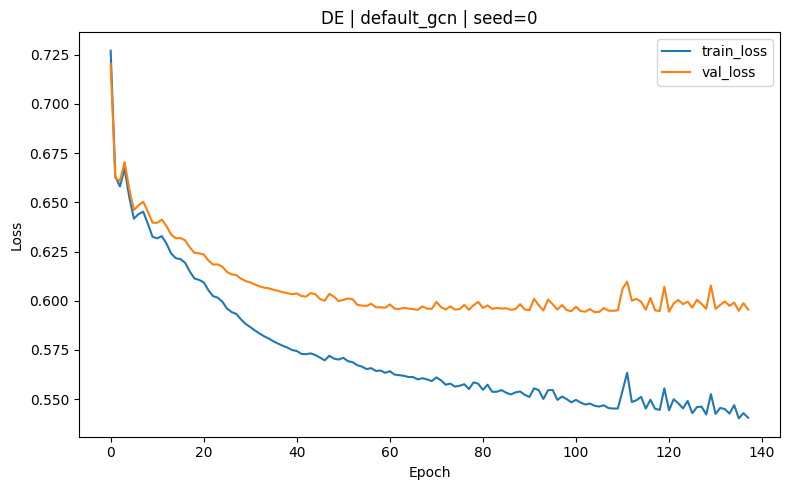

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default GCN on dataset: EN
  Seed 0 ...


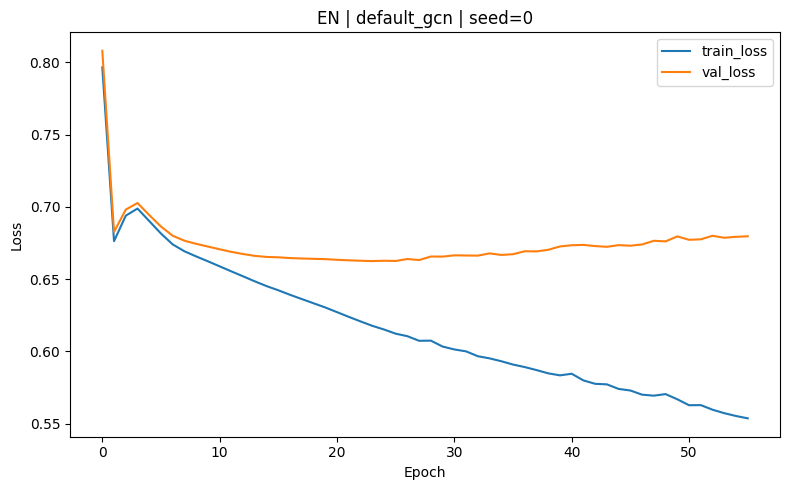

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default GCN on dataset: ES
  Seed 0 ...


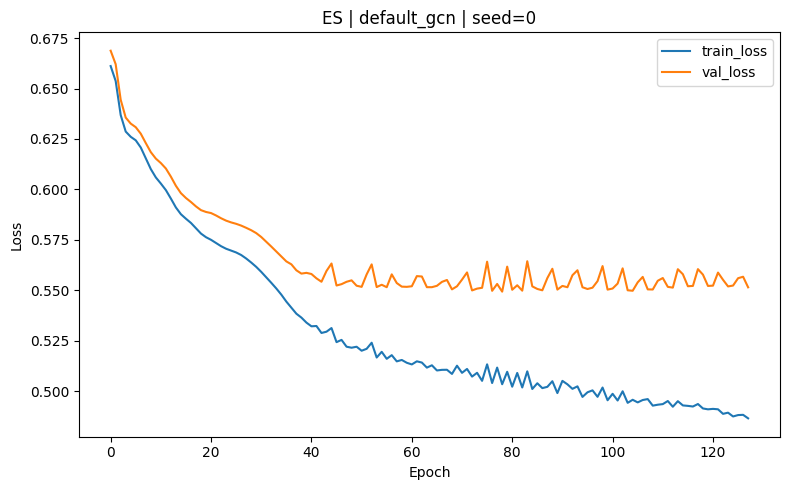

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default GCN on dataset: FR
  Seed 0 ...


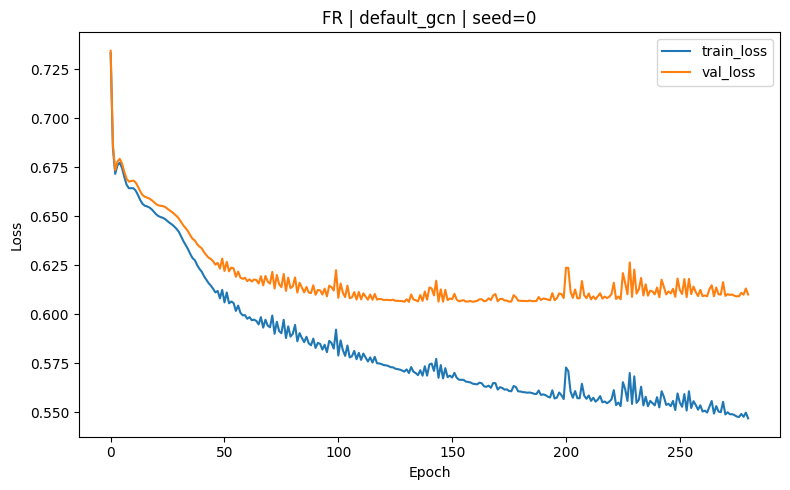

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default GCN on dataset: PT
  Seed 0 ...


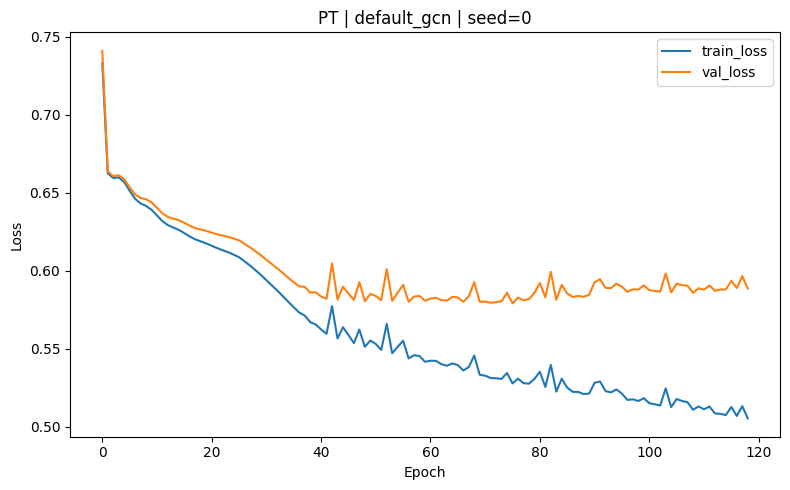

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...
Running default GCN on dataset: RU
  Seed 0 ...


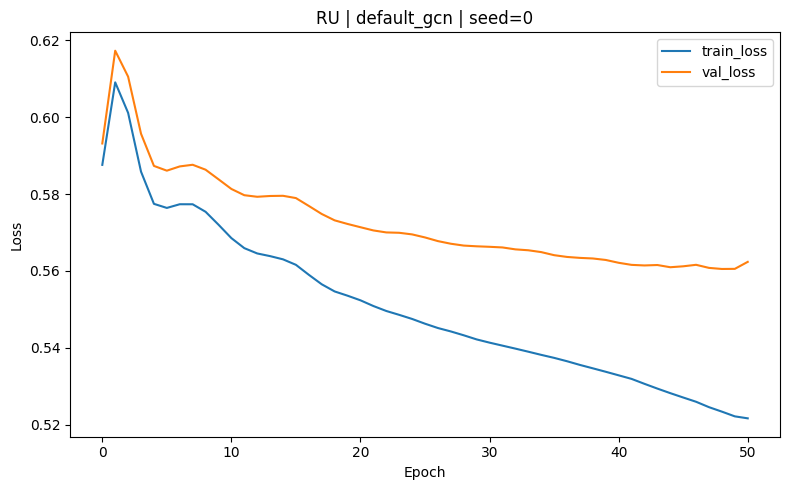

  Seed 1 ...
  Seed 2 ...
  Seed 3 ...
  Seed 4 ...


,dataset,seed,run_name,hidden_dim,num_layers,dropout,learning_rate,weight_decay,max_epochs,patience,...,train_f1,val_f1,test_f1,train_macro_f1,val_macro_f1,test_macro_f1,train_roc_auc,val_roc_auc,test_roc_auc,best_state_dict_path
0,DE,0,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.775366,0.749681,0.751269,0.702334,0.671316,0.670899,0.778606,0.726244,0.731847,outputs/models/DE_default_gcn_seed0.pt
1,DE,1,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.765823,0.742660,0.747607,0.699743,0.670521,0.680727,0.774198,0.731473,0.743752,outputs/models/DE_default_gcn_seed1.pt
2,DE,2,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.733055,0.722936,0.725615,0.690781,0.675048,0.675385,0.770602,0.733139,0.748388,outputs/models/DE_default_gcn_seed2.pt
3,DE,3,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.771133,0.742561,0.752246,0.706287,0.669728,0.678242,0.783419,0.723870,0.752925,outputs/models/DE_default_gcn_seed3.pt
4,DE,4,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.767402,0.748627,0.744323,0.693775,0.666707,0.658378,0.771656,0.734343,0.730804,outputs/models/DE_default_gcn_seed4.pt
5,EN,0,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.626116,0.594480,0.588567,0.627596,0.597866,0.591148,0.680628,0.626625,0.630622,outputs/models/EN_default_gcn_seed0.pt
6,EN,1,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.728245,0.646982,0.623926,0.700038,0.620625,0.599491,0.783052,0.651697,0.642878,outputs/models/EN_default_gcn_seed1.pt
7,EN,2,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.711205,0.646568,0.670019,0.676807,0.609884,0.626841,0.746617,0.646068,0.675196,outputs/models/EN_default_gcn_seed2.pt
8,EN,3,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.734583,0.637280,0.661260,0.697425,0.590431,0.613256,0.759565,0.636898,0.660791,outputs/models/EN_default_gcn_seed3.pt
9,EN,4,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.738100,0.676359,0.635620,0.703882,0.636287,0.588594,0.780308,0.671271,0.639541,outputs/models/EN_default_gcn_seed4.pt


Saved per-run results to: outputs/metrics/gcn_results.csv


In [9]:
# ============================================================
# Cell 8: Main experiment loop (default GCN baseline)
# ============================================================
default_results = []

for dataset_name in DATASET_NAMES:
    data_obj = dataset_data[dataset_name]["data_obj"]

    print("=" * 80)
    print(f"Running default GCN on dataset: {dataset_name}")

    for seed in SEEDS:
        print(f"  Seed {seed} ...")
        result = train_one_run(
            data_obj=data_obj,
            splits=all_splits[dataset_name][seed],
            seed=seed,
            config=DEFAULT_CONFIG,
            dataset_name=dataset_name,
            run_name="default_gcn",
            save_training_curve=(seed == SEEDS[0])  # one curve per dataset
        )

        row = {k: v for k, v in result.items() if k != "history"}
        default_results.append(row)

default_results_df = pd.DataFrame(default_results).sort_values(["dataset", "seed"]).reset_index(drop=True)
display(default_results_df.head(12))

default_results_path = os.path.join(METRICS_DIR, "gcn_results.csv")
default_results_df.to_csv(default_results_path, index=False)
print(f"Saved per-run results to: {default_results_path}")

In [10]:
# ============================================================
# Cell 9: Aggregate default results
# ============================================================
# CHANGED: the headline metric is now macro_f1 (matches MAIN_METRIC).
# We still aggregate test_f1, accuracy, and roc_auc as secondary metrics.
agg_df = (
    default_results_df
    .groupby("dataset", as_index=False)
    .agg({
        "test_macro_f1": ["mean", "std"],
        "test_f1": ["mean", "std"],
        "test_accuracy": ["mean", "std"],
        "test_roc_auc": ["mean", "std"],
        "val_macro_f1": ["mean", "std"],
        "elapsed_seconds": ["mean"]
    })
)

agg_df.columns = [
    "dataset",
    "test_macro_f1_mean", "test_macro_f1_std",
    "test_f1_mean", "test_f1_std",
    "test_accuracy_mean", "test_accuracy_std",
    "test_roc_auc_mean", "test_roc_auc_std",
    "val_macro_f1_mean", "val_macro_f1_std",
    "elapsed_seconds_mean"
]

display(agg_df)

agg_path = os.path.join(METRICS_DIR, "gcn_results_aggregated.csv")
agg_df.to_csv(agg_path, index=False)
print(f"Saved aggregated results to: {agg_path}")


,dataset,test_macro_f1_mean,test_macro_f1_std,test_f1_mean,test_f1_std,test_accuracy_mean,test_accuracy_std,test_roc_auc_mean,test_roc_auc_std,val_macro_f1_mean,val_macro_f1_std,elapsed_seconds_mean
0,DE,0.672726,0.008814,0.744212,0.010860,0.688737,0.006878,0.741543,0.009882,0.670664,0.003008,4.838368
1,EN,0.603866,0.016048,0.635878,0.032369,0.607433,0.017478,0.649806,0.017935,0.611018,0.018227,1.997333
2,ES,0.599880,0.106502,0.378008,0.216244,0.727097,0.016046,0.644057,0.157313,0.587380,0.099703,3.210741
3,FR,0.628309,0.012635,0.515625,0.013655,0.662853,0.017799,0.681840,0.009125,0.634224,0.009878,4.719835
4,PT,0.637667,0.038838,0.515462,0.035743,0.679896,0.046874,0.687034,0.027550,0.672276,0.019172,2.877025
5,RU,0.459606,0.040614,0.073980,0.101649,0.736374,0.025374,0.496614,0.049403,0.473015,0.058886,2.792855


Saved aggregated results to: outputs/metrics/gcn_results_aggregated.csv


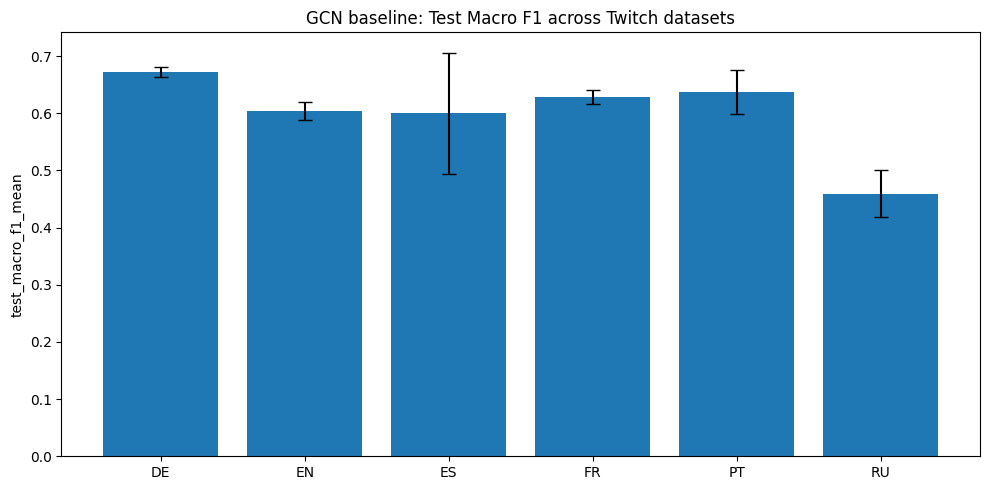

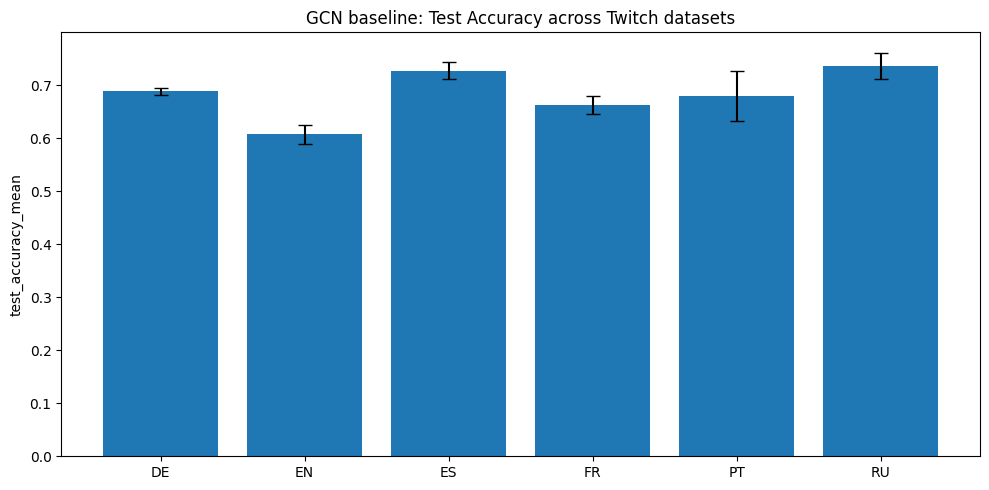

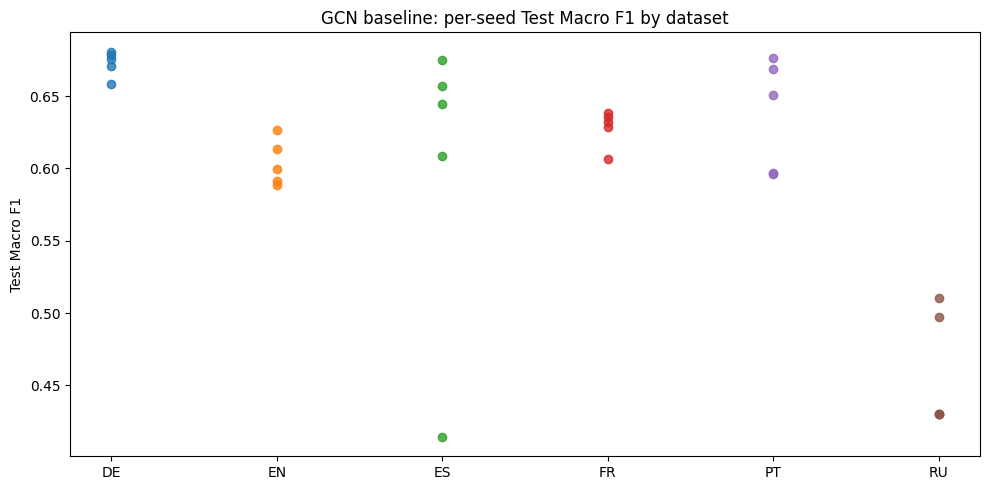

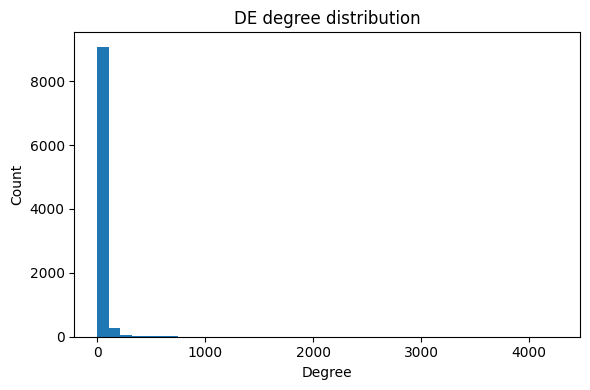

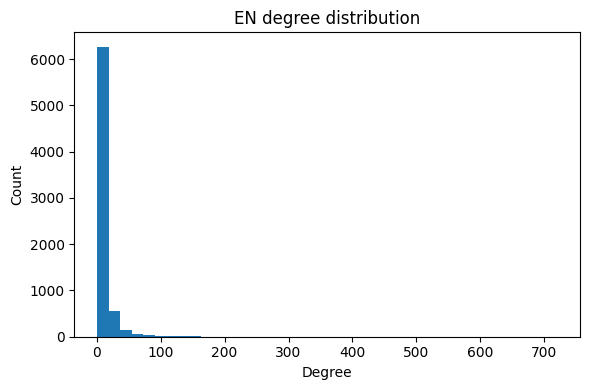

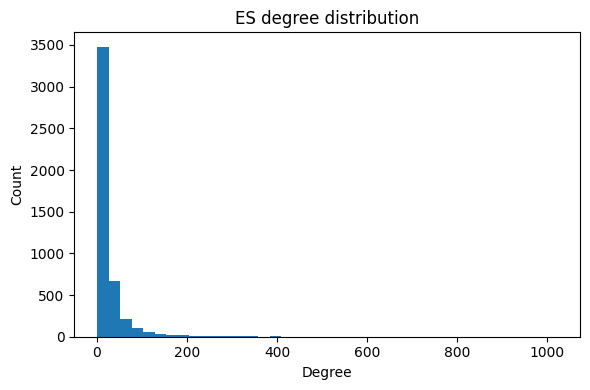

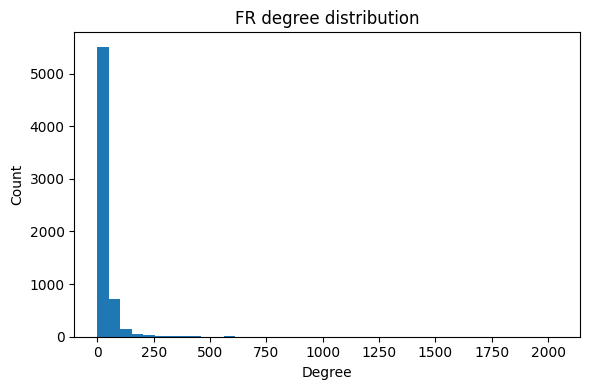

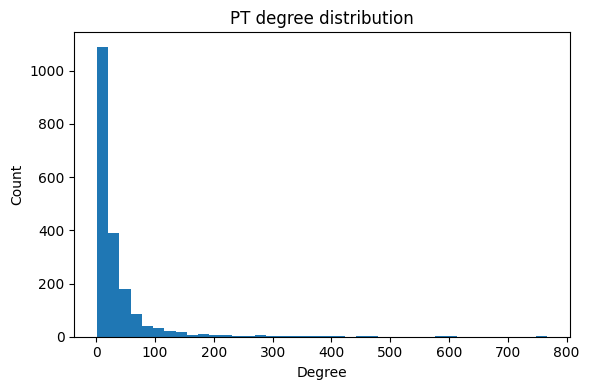

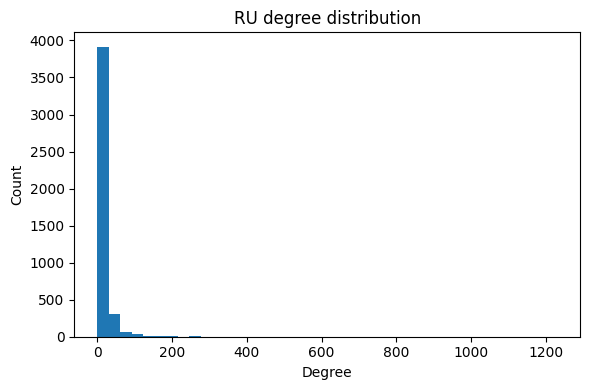

Saved default result plots.


In [12]:
# ============================================================
# Cell 10: Plots for default GCN results
# ============================================================
# CHANGED: headline bar plot is now macro F1.
plot_bar_with_error(
    df=agg_df,
    metric_col="test_macro_f1_mean",
    std_col="test_macro_f1_std",
    title="GCN baseline: Test Macro F1 across Twitch datasets",
    save_path=os.path.join(FIGURES_DIR, "gcn_test_macro_f1_barplot.png")
)

# Keep accuracy plot for context.
plot_bar_with_error(
    df=agg_df,
    metric_col="test_accuracy_mean",
    std_col="test_accuracy_std",
    title="GCN baseline: Test Accuracy across Twitch datasets",
    save_path=os.path.join(FIGURES_DIR, "gcn_test_accuracy_barplot.png")
)

# Per-seed scatter, now on macro F1.
plt.figure(figsize=(10, 5))
for i, dataset_name in enumerate(DATASET_NAMES):
    vals = default_results_df.loc[default_results_df["dataset"] == dataset_name, "test_macro_f1"].values
    x = np.full_like(vals, fill_value=i, dtype=float)
    plt.scatter(x, vals, alpha=0.8)

plt.xticks(np.arange(len(DATASET_NAMES)), DATASET_NAMES)
plt.ylabel("Test Macro F1")
plt.title("GCN baseline: per-seed Test Macro F1 by dataset")
plt.tight_layout()
scatter_path = os.path.join(FIGURES_DIR, "gcn_test_macro_f1_scatter.png")
plt.savefig(scatter_path, dpi=200)
plt.show()

# Degree histogram for each dataset (unchanged - structural diagnostic)
for dataset_name in DATASET_NAMES:
    data_obj = dataset_data[dataset_name]["data_obj"]
    deg = degree(data_obj.edge_index[0], num_nodes=data_obj.num_nodes).cpu().numpy()
    plt.figure(figsize=(6, 4))
    plt.hist(deg, bins=40)
    plt.xlabel("Degree")
    plt.ylabel("Count")
    plt.title(f"{dataset_name} degree distribution")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"{dataset_name}_degree_hist.png"), dpi=200)
    plt.show()

print("Saved default result plots.")


In [13]:
# ============================================================
# Cell 11: GCN ablations
# ============================================================
# Keep runtime manageable.
ABLATION_SEEDS = [0, 1]

ablation_results = []

# -----------------------------
# Ablation A: hidden dimension
# -----------------------------
for hidden_dim in ABLATION_GRID["hidden_dim"]:
    config = copy.deepcopy(DEFAULT_CONFIG)
    config["hidden_dim"] = hidden_dim

    for dataset_name in DATASET_NAMES:
        data_obj = dataset_data[dataset_name]["data_obj"]

        for seed in ABLATION_SEEDS:
            print(f"[Ablation hidden_dim={hidden_dim}] dataset={dataset_name}, seed={seed}")
            result = train_one_run(
                data_obj=data_obj,
                splits=all_splits[dataset_name][seed],
                seed=seed,
                config=config,
                dataset_name=dataset_name,
                run_name=f"ablation_hidden{hidden_dim}",
                save_training_curve=False
            )
            row = {k: v for k, v in result.items() if k != "history"}
            row["ablation_type"] = "hidden_dim"
            row["ablation_value"] = hidden_dim
            ablation_results.append(row)

# -----------------------------
# Ablation B: number of layers
# -----------------------------
for num_layers in ABLATION_GRID["num_layers"]:
    config = copy.deepcopy(DEFAULT_CONFIG)
    config["num_layers"] = num_layers

    for dataset_name in DATASET_NAMES:
        data_obj = dataset_data[dataset_name]["data_obj"]

        for seed in ABLATION_SEEDS:
            print(f"[Ablation num_layers={num_layers}] dataset={dataset_name}, seed={seed}")
            result = train_one_run(
                data_obj=data_obj,
                splits=all_splits[dataset_name][seed],
                seed=seed,
                config=config,
                dataset_name=dataset_name,
                run_name=f"ablation_layers{num_layers}",
                save_training_curve=False
            )
            row = {k: v for k, v in result.items() if k != "history"}
            row["ablation_type"] = "num_layers"
            row["ablation_value"] = num_layers
            ablation_results.append(row)

# -----------------------------
# Ablation C: dropout
# -----------------------------
for dropout in ABLATION_GRID["dropout"]:
    config = copy.deepcopy(DEFAULT_CONFIG)
    config["dropout"] = dropout

    for dataset_name in DATASET_NAMES:
        data_obj = dataset_data[dataset_name]["data_obj"]

        for seed in ABLATION_SEEDS:
            print(f"[Ablation dropout={dropout}] dataset={dataset_name}, seed={seed}")
            result = train_one_run(
                data_obj=data_obj,
                splits=all_splits[dataset_name][seed],
                seed=seed,
                config=config,
                dataset_name=dataset_name,
                run_name=f"ablation_dropout{dropout}",
                save_training_curve=False
            )
            row = {k: v for k, v in result.items() if k != "history"}
            row["ablation_type"] = "dropout"
            row["ablation_value"] = dropout
            ablation_results.append(row)

ablation_results_df = pd.DataFrame(ablation_results).sort_values(
    ["ablation_type", "ablation_value", "dataset", "seed"]
).reset_index(drop=True)

display(ablation_results_df.head(20))

ablation_results_path = os.path.join(METRICS_DIR, "gcn_ablation_results.csv")
ablation_results_df.to_csv(ablation_results_path, index=False)
print(f"Saved ablation results to: {ablation_results_path}")

[Ablation hidden_dim=32] dataset=DE, seed=0
[Ablation hidden_dim=32] dataset=DE, seed=1
[Ablation hidden_dim=32] dataset=EN, seed=0
[Ablation hidden_dim=32] dataset=EN, seed=1
[Ablation hidden_dim=32] dataset=ES, seed=0
[Ablation hidden_dim=32] dataset=ES, seed=1
[Ablation hidden_dim=32] dataset=FR, seed=0
[Ablation hidden_dim=32] dataset=FR, seed=1
[Ablation hidden_dim=32] dataset=PT, seed=0
[Ablation hidden_dim=32] dataset=PT, seed=1
[Ablation hidden_dim=32] dataset=RU, seed=0
[Ablation hidden_dim=32] dataset=RU, seed=1
[Ablation hidden_dim=64] dataset=DE, seed=0
[Ablation hidden_dim=64] dataset=DE, seed=1
[Ablation hidden_dim=64] dataset=EN, seed=0
[Ablation hidden_dim=64] dataset=EN, seed=1
[Ablation hidden_dim=64] dataset=ES, seed=0
[Ablation hidden_dim=64] dataset=ES, seed=1
[Ablation hidden_dim=64] dataset=FR, seed=0
[Ablation hidden_dim=64] dataset=FR, seed=1
[Ablation hidden_dim=64] dataset=PT, seed=0
[Ablation hidden_dim=64] dataset=PT, seed=1
[Ablation hidden_dim=64] dataset

,dataset,seed,run_name,hidden_dim,num_layers,dropout,learning_rate,weight_decay,max_epochs,patience,...,test_f1,train_macro_f1,val_macro_f1,test_macro_f1,train_roc_auc,val_roc_auc,test_roc_auc,best_state_dict_path,ablation_type,ablation_value
0,DE,0,ablation_dropout0.0,64,2,0.0,0.01,0.0005,300,50,...,0.738998,0.700567,0.669043,0.670496,0.774393,0.725270,0.729415,outputs/models/DE_ablation_dropout0.0_seed0.pt,dropout,0.0
1,DE,1,ablation_dropout0.0,64,2,0.0,0.01,0.0005,300,50,...,0.741922,0.716774,0.668910,0.668459,0.795304,0.728873,0.740575,outputs/models/DE_ablation_dropout0.0_seed1.pt,dropout,0.0
2,EN,0,ablation_dropout0.0,64,2,0.0,0.01,0.0005,300,50,...,0.626474,0.723256,0.598555,0.598305,0.803549,0.634228,0.637811,outputs/models/EN_ablation_dropout0.0_seed0.pt,dropout,0.0
3,EN,1,ablation_dropout0.0,64,2,0.0,0.01,0.0005,300,50,...,0.639098,0.687566,0.623668,0.590250,0.764344,0.653368,0.639030,outputs/models/EN_ablation_dropout0.0_seed1.pt,dropout,0.0
4,ES,0,ablation_dropout0.0,64,2,0.0,0.01,0.0005,300,50,...,0.471058,0.727874,0.656428,0.638031,0.842694,0.708022,0.685265,outputs/models/ES_ablation_dropout0.0_seed0.pt,dropout,0.0
5,ES,1,ablation_dropout0.0,64,2,0.0,0.01,0.0005,300,50,...,0.464208,0.702042,0.643193,0.643827,0.821269,0.675498,0.711202,outputs/models/ES_ablation_dropout0.0_seed1.pt,dropout,0.0
6,FR,0,ablation_dropout0.0,64,2,0.0,0.01,0.0005,300,50,...,0.503038,0.654739,0.639963,0.637845,0.753323,0.695502,0.696883,outputs/models/FR_ablation_dropout0.0_seed0.pt,dropout,0.0
7,FR,1,ablation_dropout0.0,64,2,0.0,0.01,0.0005,300,50,...,0.452005,0.651506,0.647555,0.600655,0.732557,0.699613,0.675318,outputs/models/FR_ablation_dropout0.0_seed1.pt,dropout,0.0
8,PT,0,ablation_dropout0.0,64,2,0.0,0.01,0.0005,300,50,...,0.493023,0.682480,0.665085,0.647601,0.791066,0.722727,0.696004,outputs/models/PT_ablation_dropout0.0_seed0.pt,dropout,0.0
9,PT,1,ablation_dropout0.0,64,2,0.0,0.01,0.0005,300,50,...,0.545455,0.710617,0.634787,0.674596,0.820470,0.673515,0.728510,outputs/models/PT_ablation_dropout0.0_seed1.pt,dropout,0.0


Saved ablation results to: outputs/metrics/gcn_ablation_results.csv


,ablation_type,ablation_value,dataset,test_macro_f1_mean,test_macro_f1_std,test_f1_mean,test_f1_std,test_accuracy_mean,test_accuracy_std
0,dropout,0.0,DE,0.669477,0.001440,0.740460,0.002067,0.684737,0.000000
1,dropout,0.0,EN,0.594277,0.005696,0.632786,0.008926,0.598177,0.002975
2,dropout,0.0,ES,0.640929,0.004098,0.467633,0.004843,0.724731,0.013686
3,dropout,0.0,FR,0.619250,0.026297,0.477521,0.036086,0.672006,0.022653
4,dropout,0.0,PT,0.661098,0.019089,0.519239,0.037075,0.720627,0.007385
5,dropout,0.0,RU,0.506436,0.030865,0.177511,0.077648,0.726340,0.017738
6,dropout,0.2,DE,0.668134,0.002455,0.736863,0.002564,0.682368,0.002605
7,dropout,0.2,EN,0.598973,0.003670,0.629240,0.004362,0.601332,0.002479
8,dropout,0.2,ES,0.638915,0.014319,0.468489,0.019980,0.719355,0.012165
9,dropout,0.2,FR,0.621183,0.015351,0.487828,0.013814,0.668192,0.018338


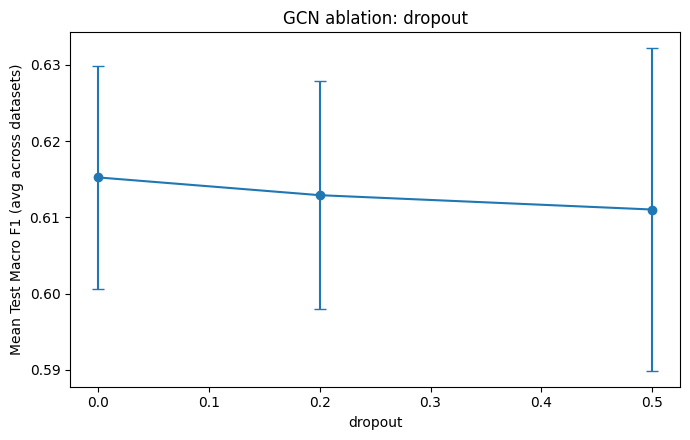

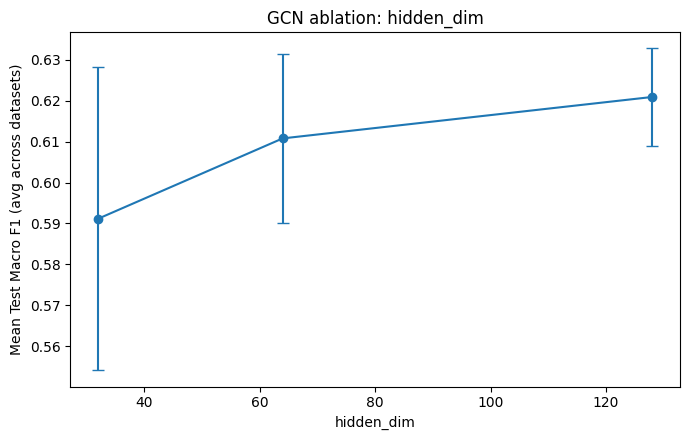

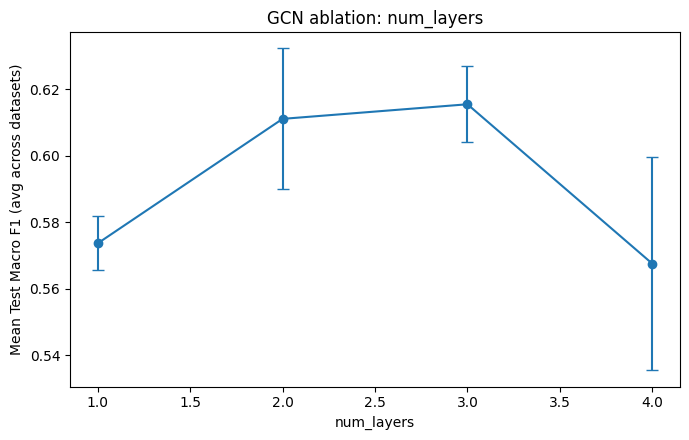

Saved ablation summary to: outputs/metrics/gcn_ablation_summary.csv


In [14]:
# ============================================================
# Cell 12: Summarize and plot ablation results
# ============================================================
# CHANGED: ablation plots use macro F1 to match the headline metric.
ablation_summary_df = (
    ablation_results_df
    .groupby(["ablation_type", "ablation_value", "dataset"], as_index=False)
    .agg({
        "test_macro_f1": ["mean", "std"],
        "test_f1": ["mean", "std"],
        "test_accuracy": ["mean", "std"]
    })
)

ablation_summary_df.columns = [
    "ablation_type", "ablation_value", "dataset",
    "test_macro_f1_mean", "test_macro_f1_std",
    "test_f1_mean", "test_f1_std",
    "test_accuracy_mean", "test_accuracy_std"
]

display(ablation_summary_df.head(20))

ablation_summary_path = os.path.join(METRICS_DIR, "gcn_ablation_summary.csv")
ablation_summary_df.to_csv(ablation_summary_path, index=False)

for ablation_type in ablation_summary_df["ablation_type"].unique():
    sub = ablation_summary_df[ablation_summary_df["ablation_type"] == ablation_type].copy()

    collapsed = (
        sub.groupby("ablation_value", as_index=False)
        .agg({
            "test_macro_f1_mean": "mean",
            "test_macro_f1_std": "mean"
        })
        .sort_values("ablation_value")
    )

    plt.figure(figsize=(7, 4.5))
    plt.errorbar(
        collapsed["ablation_value"].values,
        collapsed["test_macro_f1_mean"].values,
        yerr=collapsed["test_macro_f1_std"].values,
        marker="o",
        capsize=4
    )
    plt.xlabel(ablation_type)
    plt.ylabel("Mean Test Macro F1 (avg across datasets)")
    plt.title(f"GCN ablation: {ablation_type}")
    plt.tight_layout()

    fig_path = os.path.join(FIGURES_DIR, f"gcn_ablation_{ablation_type}.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()

print(f"Saved ablation summary to: {ablation_summary_path}")


In [15]:
# ============================================================
# Cell 13: Final summary table
# ============================================================
# CHANGED: best run per dataset is now picked by val_macro_f1 (then test_macro_f1
# as a tiebreaker), matching the new headline metric.
best_default_runs_df = (
    default_results_df
    .sort_values(["dataset", "val_macro_f1", "test_macro_f1"], ascending=[True, False, False])
    .groupby("dataset", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

final_summary_df = best_default_runs_df[[
    "dataset",
    "seed",
    "hidden_dim",
    "num_layers",
    "dropout",
    "learning_rate",
    "weight_decay",
    "best_epoch",
    "val_macro_f1",
    "test_accuracy",
    "test_f1",
    "test_macro_f1",
    "test_roc_auc"
]].copy()

display(final_summary_df)

final_summary_path = os.path.join(METRICS_DIR, "gcn_final_summary.csv")
final_summary_df.to_csv(final_summary_path, index=False)

print(f"Saved final summary to: {final_summary_path}")
print("Notebook finished successfully.")


,dataset,seed,hidden_dim,num_layers,dropout,learning_rate,weight_decay,best_epoch,val_macro_f1,test_accuracy,test_f1,test_macro_f1,test_roc_auc
0,DE,2,64,2,0.5,0.01,0.0005,79,0.675048,0.683158,0.725615,0.675385,0.748388
1,EN,4,64,2,0.5,0.01,0.0005,42,0.636287,0.593969,0.635620,0.588594,0.639541
2,ES,4,64,2,0.5,0.01,0.0005,173,0.672096,0.724731,0.503876,0.656700,0.728500
3,FR,1,64,2,0.5,0.01,0.0005,63,0.645274,0.637681,0.496288,0.606691,0.670243
4,PT,2,64,2,0.5,0.01,0.0005,83,0.697868,0.639687,0.465116,0.596731,0.653507
5,RU,4,64,2,0.5,0.01,0.0005,171,0.544004,0.705815,0.173077,0.497079,0.559945


Saved final summary to: outputs/metrics/gcn_final_summary.csv
Notebook finished successfully.


In [16]:
# ============================================================
# Compute mean Test Macro F1 for GCN by dataset
# Works whether you already have `gcn_results_df` in memory
# or only have the saved CSV on disk.
# ============================================================
# CHANGED: now aggregates Macro F1 (the team-standard headline metric).
import os
import pandas as pd

# Option 1: use in-memory dataframe if it already exists
if "gcn_results_df" in globals():
    df = gcn_results_df.copy()
# Option 2: otherwise load from CSV
else:
    gcn_csv_path = "outputs/metrics/gcn_results.csv"
    if not os.path.exists(gcn_csv_path):
        raise FileNotFoundError(f"Could not find {gcn_csv_path}")
    df = pd.read_csv(gcn_csv_path)

# Mean / std / count of test Macro F1 by dataset
gcn_mean_macro_f1_df = (
    df.groupby("dataset", as_index=False)
      .agg(
          mean_test_macro_f1=("test_macro_f1", "mean"),
          std_test_macro_f1=("test_macro_f1", "std"),
          n_runs=("test_macro_f1", "count")
      )
      .sort_values("dataset")
      .reset_index(drop=True)
)

print("GCN mean Test Macro F1 by dataset:")
display(gcn_mean_macro_f1_df)

# Overall mean across all datasets/runs
overall_mean_test_macro_f1 = df["test_macro_f1"].mean()
overall_std_test_macro_f1 = df["test_macro_f1"].std()

print(f"Overall GCN mean Test Macro F1 across all runs: {overall_mean_test_macro_f1:.6f}")
print(f"Overall GCN std Test Macro F1 across all runs:  {overall_std_test_macro_f1:.6f}")

# Save summary
save_path = "outputs/metrics/gcn_mean_test_macro_f1_summary.csv"
gcn_mean_macro_f1_df.to_csv(save_path, index=False)
print(f"Saved summary to: {save_path}")


GCN mean Test Macro F1 by dataset:


,dataset,mean_test_macro_f1,std_test_macro_f1,n_runs
0,DE,0.672726,0.008814,5
1,EN,0.603866,0.016048,5
2,ES,0.599880,0.106502,5
3,FR,0.628309,0.012635,5
4,PT,0.637667,0.038838,5
5,RU,0.459606,0.040614,5


Overall GCN mean Test Macro F1 across all runs: 0.600342
Overall GCN std Test Macro F1 across all runs:  0.082243
Saved summary to: outputs/metrics/gcn_mean_test_macro_f1_summary.csv


In [17]:
# ============================================================
# Cell 14: Create model-tagged GCN outputs for aggregation
# ============================================================
import os
import pandas as pd
import numpy as np

# Reload if needed
if "default_results_df" in globals():
    gcn_results_df = default_results_df.copy()
else:
    gcn_results_path = os.path.join(METRICS_DIR, "gcn_results.csv")
    if not os.path.exists(gcn_results_path):
        raise FileNotFoundError(f"Could not find {gcn_results_path}")
    gcn_results_df = pd.read_csv(gcn_results_path)

# Add model column so the cross-model aggregation notebook can concatenate easily
gcn_results_df["model"] = "GCN"

# Save model-tagged per-run results
gcn_for_aggregation_path = os.path.join(METRICS_DIR, "gcn_results_for_aggregation.csv")
gcn_results_df.to_csv(gcn_for_aggregation_path, index=False)

print(f"Saved model-tagged GCN results to: {gcn_for_aggregation_path}")
display(gcn_results_df.head())

Saved model-tagged GCN results to: outputs/metrics/gcn_results_for_aggregation.csv


,dataset,seed,run_name,hidden_dim,num_layers,dropout,learning_rate,weight_decay,max_epochs,patience,...,val_f1,test_f1,train_macro_f1,val_macro_f1,test_macro_f1,train_roc_auc,val_roc_auc,test_roc_auc,best_state_dict_path,model
0,DE,0,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.749681,0.751269,0.702334,0.671316,0.670899,0.778606,0.726244,0.731847,outputs/models/DE_default_gcn_seed0.pt,GCN
1,DE,1,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.742660,0.747607,0.699743,0.670521,0.680727,0.774198,0.731473,0.743752,outputs/models/DE_default_gcn_seed1.pt,GCN
2,DE,2,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.722936,0.725615,0.690781,0.675048,0.675385,0.770602,0.733139,0.748388,outputs/models/DE_default_gcn_seed2.pt,GCN
3,DE,3,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.742561,0.752246,0.706287,0.669728,0.678242,0.783419,0.723870,0.752925,outputs/models/DE_default_gcn_seed3.pt,GCN
4,DE,4,default_gcn,64,2,0.5,0.01,0.0005,300,50,...,0.748627,0.744323,0.693775,0.666707,0.658378,0.771656,0.734343,0.730804,outputs/models/DE_default_gcn_seed4.pt,GCN


In [18]:
# ============================================================
# Cell 15: Report-ready GCN mean ± std table
# ============================================================
# CHANGED: macro F1 is the lead metric in this table now.

gcn_report_summary_df = (
    gcn_results_df
    .groupby(["dataset", "model"], as_index=False)
    .agg(
        test_macro_f1_mean=("test_macro_f1", "mean"),
        test_macro_f1_std=("test_macro_f1", "std"),
        test_f1_mean=("test_f1", "mean"),
        test_f1_std=("test_f1", "std"),
        test_accuracy_mean=("test_accuracy", "mean"),
        test_accuracy_std=("test_accuracy", "std"),
        test_roc_auc_mean=("test_roc_auc", "mean"),
        test_roc_auc_std=("test_roc_auc", "std"),
        val_macro_f1_mean=("val_macro_f1", "mean"),
        val_macro_f1_std=("val_macro_f1", "std"),
        n_runs=("test_macro_f1", "count")
    )
    .sort_values("dataset")
    .reset_index(drop=True)
)

# Make human-readable columns for report/slides
for metric in ["test_macro_f1", "test_f1", "test_accuracy", "test_roc_auc"]:
    gcn_report_summary_df[f"{metric}_mean_pm_std"] = (
        gcn_report_summary_df[f"{metric}_mean"].round(3).astype(str)
        + " ± "
        + gcn_report_summary_df[f"{metric}_std"].round(3).astype(str)
    )

display(gcn_report_summary_df)

summary_path = os.path.join(METRICS_DIR, "gcn_report_summary.csv")
gcn_report_summary_df.to_csv(summary_path, index=False)
print(f"Saved report-ready summary to: {summary_path}")

# A compact slide/report table - macro F1 lead.
gcn_compact_table = gcn_report_summary_df[[
    "dataset",
    "test_macro_f1_mean_pm_std",
    "test_f1_mean_pm_std",
    "test_accuracy_mean_pm_std",
    "test_roc_auc_mean_pm_std",
    "n_runs"
]].copy()

display(gcn_compact_table)

compact_path = os.path.join(METRICS_DIR, "gcn_compact_report_table.csv")
gcn_compact_table.to_csv(compact_path, index=False)
print(f"Saved compact table to: {compact_path}")

# LaTeX table for Overleaf
latex_table = gcn_compact_table.to_latex(index=False, escape=False)
latex_path = os.path.join(METRICS_DIR, "gcn_compact_report_table.tex")

with open(latex_path, "w") as f:
    f.write(latex_table)

print(f"Saved LaTeX table to: {latex_path}")
print(latex_table)


,dataset,model,test_macro_f1_mean,test_macro_f1_std,test_f1_mean,test_f1_std,test_accuracy_mean,test_accuracy_std,test_roc_auc_mean,test_roc_auc_std,val_macro_f1_mean,val_macro_f1_std,n_runs,test_macro_f1_mean_pm_std,test_f1_mean_pm_std,test_accuracy_mean_pm_std,test_roc_auc_mean_pm_std
0,DE,GCN,0.672726,0.008814,0.744212,0.010860,0.688737,0.006878,0.741543,0.009882,0.670664,0.003008,5,0.673 ± 0.009,0.744 ± 0.011,0.689 ± 0.007,0.742 ± 0.01
1,EN,GCN,0.603866,0.016048,0.635878,0.032369,0.607433,0.017478,0.649806,0.017935,0.611018,0.018227,5,0.604 ± 0.016,0.636 ± 0.032,0.607 ± 0.017,0.65 ± 0.018
2,ES,GCN,0.599880,0.106502,0.378008,0.216244,0.727097,0.016046,0.644057,0.157313,0.587380,0.099703,5,0.6 ± 0.107,0.378 ± 0.216,0.727 ± 0.016,0.644 ± 0.157
3,FR,GCN,0.628309,0.012635,0.515625,0.013655,0.662853,0.017799,0.681840,0.009125,0.634224,0.009878,5,0.628 ± 0.013,0.516 ± 0.014,0.663 ± 0.018,0.682 ± 0.009
4,PT,GCN,0.637667,0.038838,0.515462,0.035743,0.679896,0.046874,0.687034,0.027550,0.672276,0.019172,5,0.638 ± 0.039,0.515 ± 0.036,0.68 ± 0.047,0.687 ± 0.028
5,RU,GCN,0.459606,0.040614,0.073980,0.101649,0.736374,0.025374,0.496614,0.049403,0.473015,0.058886,5,0.46 ± 0.041,0.074 ± 0.102,0.736 ± 0.025,0.497 ± 0.049


Saved report-ready summary to: outputs/metrics/gcn_report_summary.csv


,dataset,test_macro_f1_mean_pm_std,test_f1_mean_pm_std,test_accuracy_mean_pm_std,test_roc_auc_mean_pm_std,n_runs
0,DE,0.673 ± 0.009,0.744 ± 0.011,0.689 ± 0.007,0.742 ± 0.01,5
1,EN,0.604 ± 0.016,0.636 ± 0.032,0.607 ± 0.017,0.65 ± 0.018,5
2,ES,0.6 ± 0.107,0.378 ± 0.216,0.727 ± 0.016,0.644 ± 0.157,5
3,FR,0.628 ± 0.013,0.516 ± 0.014,0.663 ± 0.018,0.682 ± 0.009,5
4,PT,0.638 ± 0.039,0.515 ± 0.036,0.68 ± 0.047,0.687 ± 0.028,5
5,RU,0.46 ± 0.041,0.074 ± 0.102,0.736 ± 0.025,0.497 ± 0.049,5


Saved compact table to: outputs/metrics/gcn_compact_report_table.csv
Saved LaTeX table to: outputs/metrics/gcn_compact_report_table.tex
\begin{tabular}{lllllr}
\toprule
dataset & test_macro_f1_mean_pm_std & test_f1_mean_pm_std & test_accuracy_mean_pm_std & test_roc_auc_mean_pm_std & n_runs \\
\midrule
DE & 0.673 ± 0.009 & 0.744 ± 0.011 & 0.689 ± 0.007 & 0.742 ± 0.01 & 5 \\
EN & 0.604 ± 0.016 & 0.636 ± 0.032 & 0.607 ± 0.017 & 0.65 ± 0.018 & 5 \\
ES & 0.6 ± 0.107 & 0.378 ± 0.216 & 0.727 ± 0.016 & 0.644 ± 0.157 & 5 \\
FR & 0.628 ± 0.013 & 0.516 ± 0.014 & 0.663 ± 0.018 & 0.682 ± 0.009 & 5 \\
PT & 0.638 ± 0.039 & 0.515 ± 0.036 & 0.68 ± 0.047 & 0.687 ± 0.028 & 5 \\
RU & 0.46 ± 0.041 & 0.074 ± 0.102 & 0.736 ± 0.025 & 0.497 ± 0.049 & 5 \\
\bottomrule
\end{tabular}



In [19]:
# ============================================================
# Cell 16: Add richer graph statistics for report interpretation
# ============================================================
# This gives you diagnostics to connect GCN/GAT/GraphSAGE performance
# to graph structure: degree heterogeneity, clustering, components, etc.

import networkx as nx
import numpy as np
import pandas as pd
from torch_geometric.utils import degree, homophily

def degree_gini(degrees: np.ndarray) -> float:
    degrees = np.asarray(degrees, dtype=float)
    if len(degrees) == 0 or degrees.sum() == 0:
        return 0.0
    sorted_degrees = np.sort(degrees)
    n = len(sorted_degrees)
    cumulative = np.cumsum(sorted_degrees)
    return float((n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n)

def sampled_average_clustering(G: nx.Graph, max_nodes: int = 2000, seed: int = 0) -> float:
    nodes = list(G.nodes())
    if len(nodes) == 0:
        return np.nan
    rng = np.random.default_rng(seed)
    if len(nodes) > max_nodes:
        sampled_nodes = rng.choice(nodes, size=max_nodes, replace=False).tolist()
    else:
        sampled_nodes = nodes
    clustering_vals = nx.clustering(G, nodes=sampled_nodes)
    return float(np.mean(list(clustering_vals.values())))

enhanced_rows = []

for dataset_name in DATASET_NAMES:
    data_obj = dataset_data[dataset_name]["data_obj"]

    num_nodes = int(data_obj.num_nodes)
    edge_index_np = data_obj.edge_index.detach().cpu().numpy()

    # Build undirected NetworkX graph.
    # data_obj.edge_index was already made undirected, so NetworkX will deduplicate.
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))
    G.add_edges_from(edge_index_np.T.tolist())

    degrees = np.array([d for _, d in G.degree()], dtype=float)

    if num_nodes > 0:
        isolated_frac = float((degrees == 0).mean())
    else:
        isolated_frac = np.nan

    connected_components = list(nx.connected_components(G))
    num_components = len(connected_components)
    largest_component_size = max((len(c) for c in connected_components), default=0)
    largest_component_frac = largest_component_size / num_nodes if num_nodes > 0 else np.nan

    # Exact transitivity is usually okay; sampled local clustering is faster than exact average clustering.
    try:
        global_transitivity = float(nx.transitivity(G))
    except Exception:
        global_transitivity = np.nan

    try:
        avg_clustering_sampled = sampled_average_clustering(G, max_nodes=2000, seed=0)
    except Exception:
        avg_clustering_sampled = np.nan

    try:
        edge_hom = float(homophily(data_obj.edge_index, data_obj.y, method="edge"))
    except Exception:
        edge_hom = np.nan

    enhanced_rows.append({
        "dataset": dataset_name,
        "num_nodes": num_nodes,
        "num_edges_undirected": int(G.number_of_edges()),
        "avg_degree": float(degrees.mean()) if len(degrees) else np.nan,
        "std_degree": float(degrees.std()) if len(degrees) else np.nan,
        "max_degree": int(degrees.max()) if len(degrees) else 0,
        "degree_cv": float(degrees.std() / degrees.mean()) if degrees.mean() > 0 else np.nan,
        "degree_gini": degree_gini(degrees),
        "isolated_node_fraction": isolated_frac,
        "num_connected_components": num_components,
        "largest_component_size": int(largest_component_size),
        "largest_component_fraction": float(largest_component_frac),
        "global_transitivity": global_transitivity,
        "avg_clustering_sampled": avg_clustering_sampled,
        "edge_homophily": edge_hom,
        "class_1_fraction": float(data_obj.y.detach().cpu().numpy().mean())
    })

enhanced_graph_stats_df = pd.DataFrame(enhanced_rows).sort_values("dataset").reset_index(drop=True)

display(enhanced_graph_stats_df)

enhanced_stats_path = os.path.join(METRICS_DIR, "gcn_enhanced_graph_statistics.csv")
enhanced_graph_stats_df.to_csv(enhanced_stats_path, index=False)
print(f"Saved enhanced graph statistics to: {enhanced_stats_path}")

,dataset,num_nodes,num_edges_undirected,avg_degree,std_degree,max_degree,degree_cv,degree_gini,isolated_node_fraction,num_connected_components,largest_component_size,largest_component_fraction,global_transitivity,avg_clustering_sampled,edge_homophily,class_1_fraction
0,DE,9498,153138,32.246368,84.797544,4259,2.629677,0.630375,0.000000,1,9498,1.000000,0.046471,0.200560,0.632234,0.604548
1,EN,7126,35324,9.914117,22.188706,720,2.238092,0.610576,0.000000,1,7126,1.000000,0.042433,0.133143,0.555996,0.545608
2,ES,4648,59382,25.551635,49.394543,1022,1.933127,0.627262,0.000000,1,4648,1.000000,0.084235,0.221808,0.579991,0.292599
3,FR,6551,112666,34.396581,77.482702,2040,2.252628,0.606625,0.000305,3,6549,0.999695,0.054128,0.227519,0.559450,0.368799
4,PT,1912,31299,32.739540,55.837791,767,1.705515,0.606880,0.000000,1,1912,1.000000,0.130981,0.319895,0.570849,0.345711
5,RU,4385,37304,17.014367,41.677658,1229,2.449557,0.630880,0.000000,1,4385,1.000000,0.048648,0.165790,0.617628,0.245154


Saved enhanced graph statistics to: outputs/metrics/gcn_enhanced_graph_statistics.csv


In [20]:
# ============================================================
# Cell 17: GCN depth ablation summary for oversmoothing discussion
# ============================================================
# This isolates the number-of-layers ablation, the most relevant GCN-specific
# ablation for the report.
# CHANGED: uses macro_f1 (matches MAIN_METRIC).

if "ablation_results_df" in globals():
    gcn_ablation_df = ablation_results_df.copy()
else:
    ablation_path = os.path.join(METRICS_DIR, "gcn_ablation_results.csv")
    if not os.path.exists(ablation_path):
        raise FileNotFoundError(f"Could not find {ablation_path}")
    gcn_ablation_df = pd.read_csv(ablation_path)

gcn_ablation_df["model"] = "GCN"

depth_df = gcn_ablation_df[gcn_ablation_df["ablation_type"] == "num_layers"].copy()

if depth_df.empty:
    print("No num_layers ablation found.")
else:
    depth_summary_by_dataset = (
        depth_df
        .groupby(["dataset", "ablation_value"], as_index=False)
        .agg(
            test_macro_f1_mean=("test_macro_f1", "mean"),
            test_macro_f1_std=("test_macro_f1", "std"),
            test_accuracy_mean=("test_accuracy", "mean"),
            test_accuracy_std=("test_accuracy", "std"),
            n_runs=("test_macro_f1", "count")
        )
        .rename(columns={"ablation_value": "num_layers"})
        .sort_values(["dataset", "num_layers"])
        .reset_index(drop=True)
    )

    display(depth_summary_by_dataset)

    depth_by_dataset_path = os.path.join(METRICS_DIR, "gcn_depth_ablation_by_dataset.csv")
    depth_summary_by_dataset.to_csv(depth_by_dataset_path, index=False)
    print(f"Saved depth ablation by dataset to: {depth_by_dataset_path}")

    depth_summary_overall = (
        depth_summary_by_dataset
        .groupby("num_layers", as_index=False)
        .agg(
            test_macro_f1_mean_across_datasets=("test_macro_f1_mean", "mean"),
            test_macro_f1_std_across_datasets=("test_macro_f1_mean", "std")
        )
        .sort_values("num_layers")
        .reset_index(drop=True)
    )

    display(depth_summary_overall)

    depth_overall_path = os.path.join(METRICS_DIR, "gcn_depth_ablation_overall.csv")
    depth_summary_overall.to_csv(depth_overall_path, index=False)
    print(f"Saved overall depth ablation to: {depth_overall_path}")


,dataset,num_layers,test_macro_f1_mean,test_macro_f1_std,test_accuracy_mean,test_accuracy_std,n_runs
0,DE,1.0,0.633012,0.004604,0.670000,0.002233,2
1,DE,2.0,0.675813,0.006950,0.692632,0.002977,2
2,DE,3.0,0.665512,0.000273,0.678158,0.003349,2
3,DE,4.0,0.653587,0.001020,0.664737,0.002233,2
4,EN,1.0,0.595010,0.012740,0.608696,0.004959,2
5,EN,2.0,0.595319,0.005900,0.596073,0.006942,2
6,EN,3.0,0.600476,0.018790,0.604488,0.021818,2
7,EN,4.0,0.594192,0.011941,0.595021,0.011405,2
8,ES,1.0,0.570525,0.008383,0.729032,0.006083,2
9,ES,2.0,0.626551,0.024944,0.725806,0.006083,2


Saved depth ablation by dataset to: outputs/metrics/gcn_depth_ablation_by_dataset.csv


,num_layers,test_macro_f1_mean_across_datasets,test_macro_f1_std_across_datasets
0,1.0,0.573650,0.067462
1,2.0,0.611140,0.072988
2,3.0,0.615534,0.043339
3,4.0,0.567529,0.080551


Saved overall depth ablation to: outputs/metrics/gcn_depth_ablation_overall.csv


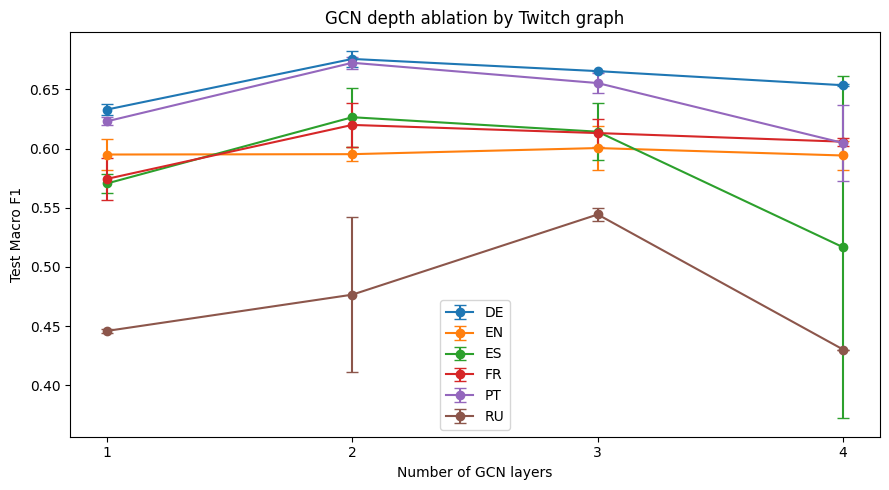

Saved depth ablation by dataset figure to: outputs/figures/gcn_depth_ablation_by_dataset.png


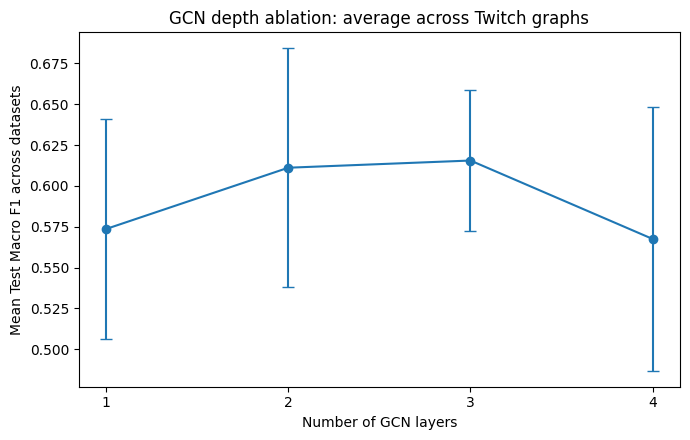

Saved overall depth ablation figure to: outputs/figures/gcn_depth_ablation_overall.png


In [21]:
# ============================================================
# Cell 18: Plot GCN depth ablation cleanly
# ============================================================
# CHANGED: macro F1 axis.

if "depth_summary_by_dataset" in globals() and not depth_summary_by_dataset.empty:
    # Plot one line per dataset
    plt.figure(figsize=(9, 5))

    for dataset_name in DATASET_NAMES:
        sub = depth_summary_by_dataset[depth_summary_by_dataset["dataset"] == dataset_name]
        if sub.empty:
            continue
        plt.errorbar(
            sub["num_layers"].values,
            sub["test_macro_f1_mean"].values,
            yerr=sub["test_macro_f1_std"].values,
            marker="o",
            capsize=4,
            label=dataset_name
        )

    plt.xlabel("Number of GCN layers")
    plt.ylabel("Test Macro F1")
    plt.title("GCN depth ablation by Twitch graph")
    plt.xticks(sorted(depth_summary_by_dataset["num_layers"].unique()))
    plt.legend()
    plt.tight_layout()

    depth_fig_path = os.path.join(FIGURES_DIR, "gcn_depth_ablation_by_dataset.png")
    plt.savefig(depth_fig_path, dpi=200)
    plt.show()

    print(f"Saved depth ablation by dataset figure to: {depth_fig_path}")

if "depth_summary_overall" in globals() and not depth_summary_overall.empty:
    plt.figure(figsize=(7, 4.5))
    plt.errorbar(
        depth_summary_overall["num_layers"].values,
        depth_summary_overall["test_macro_f1_mean_across_datasets"].values,
        yerr=depth_summary_overall["test_macro_f1_std_across_datasets"].values,
        marker="o",
        capsize=4
    )

    plt.xlabel("Number of GCN layers")
    plt.ylabel("Mean Test Macro F1 across datasets")
    plt.title("GCN depth ablation: average across Twitch graphs")
    plt.xticks(sorted(depth_summary_overall["num_layers"].unique()))
    plt.tight_layout()

    depth_overall_fig_path = os.path.join(FIGURES_DIR, "gcn_depth_ablation_overall.png")
    plt.savefig(depth_overall_fig_path, dpi=200)
    plt.show()

    print(f"Saved overall depth ablation figure to: {depth_overall_fig_path}")


In [22]:
# ============================================================
# Cell 19: Create a reproducibility manifest
# ============================================================
# This is useful for the report's reproducibility criterion.

manifest = {
    "model": "GCN",
    "datasets": DATASET_NAMES,
    "seeds": SEEDS,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "main_metric": MAIN_METRIC,
    "default_config": DEFAULT_CONFIG,
    "ablation_grid": ABLATION_GRID,
    "ablation_seeds": ABLATION_SEEDS if "ABLATION_SEEDS" in globals() else None,
    "device": str(DEVICE),
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "metrics_dir": METRICS_DIR,
    "figures_dir": FIGURES_DIR,
    "models_dir": MODELS_DIR,
    "splits_dir": SPLITS_DIR,
}

manifest_path = os.path.join(METRICS_DIR, "gcn_reproducibility_manifest.json")

with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Saved reproducibility manifest to: {manifest_path}")
print(json.dumps(manifest, indent=2))

Saved reproducibility manifest to: outputs/metrics/gcn_reproducibility_manifest.json
{
  "model": "GCN",
  "datasets": [
    "DE",
    "EN",
    "ES",
    "FR",
    "PT",
    "RU"
  ],
  "seeds": [
    0,
    1,
    2,
    3,
    4
  ],
  "train_ratio": 0.6,
  "val_ratio": 0.2,
  "test_ratio": 0.2,
  "main_metric": "macro_f1",
  "default_config": {
    "hidden_dim": 64,
    "num_layers": 2,
    "dropout": 0.5,
    "learning_rate": 0.01,
    "weight_decay": 0.0005,
    "max_epochs": 300,
    "patience": 50
  },
  "ablation_grid": {
    "hidden_dim": [
      32,
      64,
      128
    ],
    "num_layers": [
      1,
      2,
      3,
      4
    ],
    "dropout": [
      0.0,
      0.2,
      0.5
    ]
  },
  "ablation_seeds": [
    0,
    1
  ],
  "device": "cuda",
  "torch_version": "2.10.0+cu128",
  "cuda_available": true,
  "metrics_dir": "outputs/metrics",
  "figures_dir": "outputs/figures",
  "models_dir": "outputs/models",
  "splits_dir": "outputs/splits"
}


In [23]:
# ============================================================
# Cell 20: Copy outputs to a shared Google Drive folder
# ============================================================
# Use this if your group wants the aggregation notebook to read everyone's files
# from one common Drive folder.
#
# IMPORTANT:
# Change PROJECT_DIR to your group's actual shared folder.

USE_GOOGLE_DRIVE_COPY = False  # set to True when ready

if USE_GOOGLE_DRIVE_COPY:
    from google.colab import drive
    import shutil

    drive.mount("/content/drive")

    PROJECT_DIR = "/content/drive/MyDrive/stat 175 group project"  # change this if needed
    SHARED_OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")

    os.makedirs(SHARED_OUTPUT_DIR, exist_ok=True)

    # Copy local outputs into shared Drive outputs folder
    shutil.copytree(ROOT_OUTPUT_DIR, SHARED_OUTPUT_DIR, dirs_exist_ok=True)

    print(f"Copied local {ROOT_OUTPUT_DIR}/ to shared folder:")
    print(SHARED_OUTPUT_DIR)

    print("Shared metrics files:")
    shared_metrics_dir = os.path.join(SHARED_OUTPUT_DIR, "metrics")
    for filename in sorted(os.listdir(shared_metrics_dir)):
        if filename.startswith("gcn"):
            print("  ", filename)
else:
    print("Google Drive copy skipped. Set USE_GOOGLE_DRIVE_COPY = True when ready.")

Google Drive copy skipped. Set USE_GOOGLE_DRIVE_COPY = True when ready.


In [24]:
# ============================================================
# Paper-focused GCN figures only
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PAPER_FIGURES_DIR = os.path.join(ROOT_OUTPUT_DIR, "paper_figures")
os.makedirs(PAPER_FIGURES_DIR, exist_ok=True)

# Load main GCN results
if "default_results_df" in globals():
    gcn_results_df = default_results_df.copy()
else:
    gcn_results_df = pd.read_csv(os.path.join(METRICS_DIR, "gcn_results.csv"))

# Load ablation results
if "ablation_results_df" in globals():
    gcn_ablation_df = ablation_results_df.copy()
else:
    gcn_ablation_df = pd.read_csv(os.path.join(METRICS_DIR, "gcn_ablation_results.csv"))

# Load graph statistics
if "dataset_summary_df" in globals():
    graph_stats_df = dataset_summary_df.copy()
else:
    graph_stats_df = pd.read_csv(os.path.join(METRICS_DIR, "gcn_dataset_summary.csv"))

DATASET_ORDER = ["DE", "EN", "ES", "FR", "PT", "RU"]

,dataset,test_macro_f1_mean,test_macro_f1_std,test_f1_mean,test_f1_std,n_runs
0,DE,0.672726,0.008814,0.744212,0.010860,5
1,EN,0.603866,0.016048,0.635878,0.032369,5
2,ES,0.599880,0.106502,0.378008,0.216244,5
3,FR,0.628309,0.012635,0.515625,0.013655,5
4,PT,0.637667,0.038838,0.515462,0.035743,5
5,RU,0.459606,0.040614,0.073980,0.101649,5


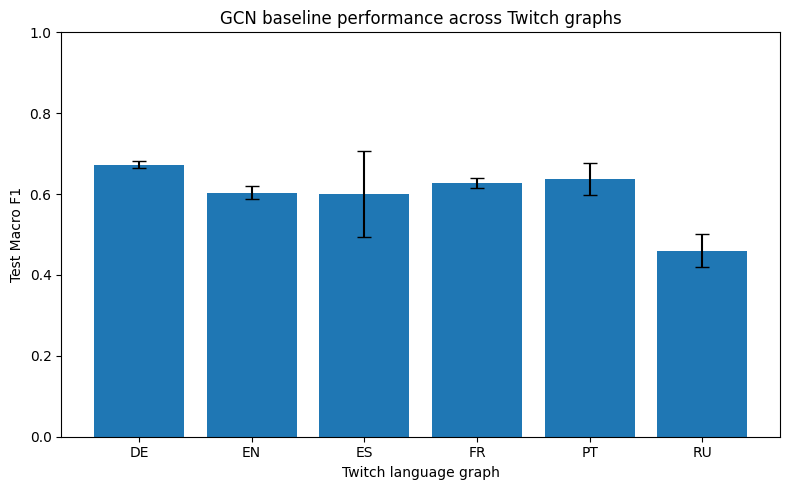

Saved: outputs/paper_figures/gcn_test_macro_f1_by_dataset.png


In [25]:
# ============================================================
# Figure 1: GCN Test Macro F1 by dataset
# ============================================================
# CHANGED: paper figure 1 reports macro F1 (the headline metric).

gcn_summary = (
    gcn_results_df
    .groupby("dataset", as_index=False)
    .agg(
        test_macro_f1_mean=("test_macro_f1", "mean"),
        test_macro_f1_std=("test_macro_f1", "std"),
        test_f1_mean=("test_f1", "mean"),
        test_f1_std=("test_f1", "std"),
        n_runs=("test_macro_f1", "count")
    )
)

gcn_summary["dataset"] = pd.Categorical(
    gcn_summary["dataset"],
    categories=DATASET_ORDER,
    ordered=True
)
gcn_summary = gcn_summary.sort_values("dataset")

display(gcn_summary)

plt.figure(figsize=(8, 5))
x = np.arange(len(gcn_summary))

plt.bar(
    x,
    gcn_summary["test_macro_f1_mean"],
    yerr=gcn_summary["test_macro_f1_std"],
    capsize=5
)

plt.xticks(x, gcn_summary["dataset"])
plt.ylabel("Test Macro F1")
plt.xlabel("Twitch language graph")
plt.title("GCN baseline performance across Twitch graphs")
plt.ylim(0, 1)
plt.tight_layout()

fig_path = os.path.join(PAPER_FIGURES_DIR, "gcn_test_macro_f1_by_dataset.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path}")


,num_layers,test_macro_f1_mean,test_macro_f1_std,n_runs
0,1.0,0.573650,0.064730,12
1,2.0,0.611140,0.073029,12
2,3.0,0.615534,0.042601,12
3,4.0,0.567529,0.088918,12


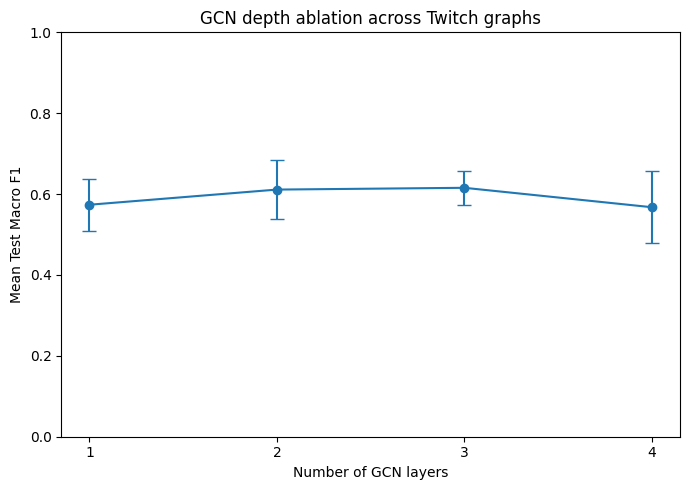

Saved: outputs/paper_figures/gcn_depth_ablation.png


In [26]:
# ============================================================
# Figure 2: GCN depth ablation
# ============================================================
# CHANGED: macro F1 axis.

depth_df = gcn_ablation_df[gcn_ablation_df["ablation_type"] == "num_layers"].copy()

if depth_df.empty:
    print("No num_layers ablation found in gcn_ablation_results.csv")
else:
    depth_summary = (
        depth_df
        .groupby("ablation_value", as_index=False)
        .agg(
            test_macro_f1_mean=("test_macro_f1", "mean"),
            test_macro_f1_std=("test_macro_f1", "std"),
            n_runs=("test_macro_f1", "count")
        )
        .rename(columns={"ablation_value": "num_layers"})
        .sort_values("num_layers")
    )

    display(depth_summary)

    plt.figure(figsize=(7, 5))

    plt.errorbar(
        depth_summary["num_layers"],
        depth_summary["test_macro_f1_mean"],
        yerr=depth_summary["test_macro_f1_std"],
        marker="o",
        capsize=5
    )

    plt.xlabel("Number of GCN layers")
    plt.ylabel("Mean Test Macro F1")
    plt.title("GCN depth ablation across Twitch graphs")
    plt.xticks(depth_summary["num_layers"])
    plt.ylim(0, 1)
    plt.tight_layout()

    fig_path = os.path.join(PAPER_FIGURES_DIR, "gcn_depth_ablation.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print(f"Saved: {fig_path}")


,dataset,test_macro_f1_mean,test_macro_f1_std,test_f1_mean,test_f1_std,n_runs,num_nodes,num_edges_directed_count,num_edges_undirected_approx,num_features,...,feature_std,density_undirected_approx,dropped_edges_due_to_id_mismatch,edge_id_mode,avg_degree_directed_count,std_degree_directed_count,max_degree_directed_count,homophily_edge,num_edges_after_undirected,degree_cv
0,DE,0.672726,0.008814,0.744212,0.010860,5,9498,153138,153138,3170,...,0.079833,0.003395,0,new_id,16.123184,43.326980,1260,0.632234,306276,2.687247
1,EN,0.603866,0.016048,0.635878,0.032369,5,7126,35324,35324,3170,...,0.080591,0.001391,0,new_id,4.957059,14.080254,540,0.555996,70648,2.840445
2,ES,0.599880,0.106502,0.378008,0.216244,5,4648,59382,59382,3170,...,0.077829,0.005499,0,new_id,12.775818,28.757542,618,0.579991,118764,2.250936
3,FR,0.628309,0.012635,0.515625,0.013655,5,6551,112666,112666,3170,...,0.078577,0.005251,0,new_id,17.198290,47.013575,1489,0.559450,225332,2.733619
4,PT,0.637667,0.038838,0.515462,0.035743,5,1912,31299,31299,3169,...,0.078964,0.017132,0,new_id,16.369770,36.074609,714,0.570849,62598,2.203733
5,RU,0.459606,0.040614,0.073980,0.101649,5,4385,37304,37304,3170,...,0.080330,0.003881,0,new_id,8.507184,26.591757,756,0.617628,74608,3.125800


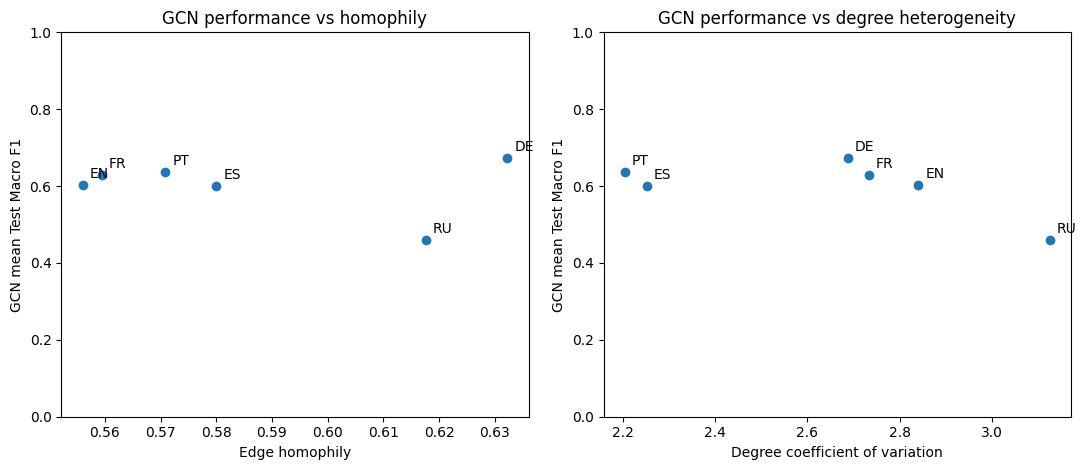

Saved: outputs/paper_figures/gcn_performance_vs_graph_structure.png


In [27]:
# ============================================================
# Figure 3: GCN performance vs graph structure
# ============================================================
# CHANGED: y-axis is now macro F1.

structure_df = gcn_summary.merge(graph_stats_df, on="dataset", how="left")

# Make sure degree_cv exists
if "degree_cv" not in structure_df.columns:
    if "std_degree_directed_count" in structure_df.columns and "avg_degree_directed_count" in structure_df.columns:
        structure_df["degree_cv"] = (
            structure_df["std_degree_directed_count"]
            / structure_df["avg_degree_directed_count"]
        )
    else:
        structure_df["degree_cv"] = np.nan

# Make sure homophily column exists
homophily_col = None
for candidate in ["homophily_edge", "edge_homophily"]:
    if candidate in structure_df.columns:
        homophily_col = candidate
        break

display(structure_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# Panel A: Macro F1 vs homophily
if homophily_col is not None and structure_df[homophily_col].notna().any():
    axes[0].scatter(structure_df[homophily_col], structure_df["test_macro_f1_mean"])

    for _, row in structure_df.iterrows():
        axes[0].annotate(
            row["dataset"],
            (row[homophily_col], row["test_macro_f1_mean"]),
            textcoords="offset points",
            xytext=(5, 5)
        )

    axes[0].set_xlabel("Edge homophily")
    axes[0].set_ylabel("GCN mean Test Macro F1")
    axes[0].set_title("GCN performance vs homophily")
    axes[0].set_ylim(0, 1)
else:
    axes[0].text(0.5, 0.5, "Homophily not available", ha="center", va="center")
    axes[0].set_axis_off()

# Panel B: Macro F1 vs degree heterogeneity
if structure_df["degree_cv"].notna().any():
    axes[1].scatter(structure_df["degree_cv"], structure_df["test_macro_f1_mean"])

    for _, row in structure_df.iterrows():
        axes[1].annotate(
            row["dataset"],
            (row["degree_cv"], row["test_macro_f1_mean"]),
            textcoords="offset points",
            xytext=(5, 5)
        )

    axes[1].set_xlabel("Degree coefficient of variation")
    axes[1].set_ylabel("GCN mean Test Macro F1")
    axes[1].set_title("GCN performance vs degree heterogeneity")
    axes[1].set_ylim(0, 1)
else:
    axes[1].text(0.5, 0.5, "Degree CV not available", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()

fig_path = os.path.join(PAPER_FIGURES_DIR, "gcn_performance_vs_graph_structure.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path}")


In [28]:
# ============================================================
# Save only the useful GCN table for later aggregation
# ============================================================

gcn_summary_for_report = gcn_summary.copy()
gcn_summary_for_report["model"] = "GCN"

summary_path = os.path.join(METRICS_DIR, "gcn_summary_for_report.csv")
gcn_summary_for_report.to_csv(summary_path, index=False)

print(f"Saved compact GCN summary to: {summary_path}")
display(gcn_summary_for_report)

Saved compact GCN summary to: outputs/metrics/gcn_summary_for_report.csv


,dataset,test_macro_f1_mean,test_macro_f1_std,test_f1_mean,test_f1_std,n_runs,model
0,DE,0.672726,0.008814,0.744212,0.010860,5,GCN
1,EN,0.603866,0.016048,0.635878,0.032369,5,GCN
2,ES,0.599880,0.106502,0.378008,0.216244,5,GCN
3,FR,0.628309,0.012635,0.515625,0.013655,5,GCN
4,PT,0.637667,0.038838,0.515462,0.035743,5,GCN
5,RU,0.459606,0.040614,0.073980,0.101649,5,GCN


## Zip and download all GCN outputs

Run this cell at the very end. It packages the entire `outputs/` folder
into a single zip and triggers a browser download in Colab.


In [29]:
# ============================================================
# Zip outputs and download
# ============================================================
zip_path = "/content/gcn_outputs.zip"
!zip -r -q {zip_path} {ROOT_OUTPUT_DIR}
print("Created:", zip_path)

# In Colab, this triggers a direct download.
from google.colab import files
files.download(zip_path)


Created: /content/gcn_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>